In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

from sklearn.preprocessing import LabelEncoder

# ============================================================
# Display Settings
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", "{:.2f}".format)

plt.style.use("ggplot")

# ============================================================
# Load Dataset
# ============================================================

KAGGLE_PATH = "/kaggle/input/datasets/aiexplorer77/cyber-attack-detection-and-risk-prediction-dataset/Enterprise_Cyber_Kill_Chain_Dataset.csv"
LOCAL_PATH = "Enterprise_Cyber_Kill_Chain_Dataset.csv"

try:
    df = pd.read_csv(KAGGLE_PATH)
except FileNotFoundError:
    df = pd.read_csv(LOCAL_PATH)

# ============================================================
# Dataset Information
# ============================================================

print("=" * 60)
print("Cyber Attack Detection and Risk Analysis Dataset")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

df.head()

Cyber Attack Detection and Risk Analysis Dataset
Rows    : 100,500
Columns : 50


,Incident_ID,Timestamp,Industry,Country,Company_Size,Employee_Count,Attack_Vector,Threat_Actor,Firewall,MFA,EDR,IDS,Security_Training,Password_Policy,Patch_Age_Days,Open_Vulnerabilities,CVSS_Score,Internet_Exposed,Security_Audit_Score,Phishing_Click,Credential_Stolen,Privilege_Escalation,Lateral_Movement,Persistence,Data_Encrypted,Data_Exfiltration_GB,Attack_Success,Attack_Stage,Attack_Complexity,Detection_Time_Min,Response_Time_Min,Downtime_Hours,Records_Compromised,Financial_Loss_USD,Recovery_Cost_USD,Cyber_Risk_Score,Risk_Level,Incident_Severity,Hour,DayOfWeek,Month,Business_Hours,Weekend,Zero_Day,Compliance,Vendor_Count,ThirdParty_Risk,Insider_Risk,Security_Maturity,SOC_Team_Size
0,78303,2025-03-26 15:30:00,Government,Canada,Small,193,Cloud,Script Kiddie,1,0,1,1,0,Moderate,91,3,3.80,0,89.00,0,0,0,0,0,0,0.00,0,Reconnaissance,Basic,83.00,5,1.16,0.00,5512.68,NaN,34.03,Medium,Moderate,15,Wednesday,March,1,0,0,NIST,7,12.20,59.90,60,3
1,66465,2024-11-23 08:00:00,Retail,UK,Small,218,Web,Nation State,1,1,1,1,0,Strong,52,2,4.10,1,95.70,0,0,0,0,0,0,0.00,0,Reconnaissance,Advanced,72.00,5,0.16,0.00,18035.00,NaN,39.82,Medium,Moderate,8,Saturday,November,0,1,1,NaN,4,50.20,53.60,80,3
2,93228,2025-08-29 02:45:00,Education,Australia,Small,33,Cloud,Cyber Criminal,1,1,1,1,1,Weak,59,6,4.40,0,75.30,1,0,0,0,0,0,0.00,0,Reconnaissance,Intermediate,84.00,6,2.54,0.00,16821.45,NaN,33.28,Medium,Moderate,2,Friday,August,0,0,0,NaN,2,23.40,12.70,100,3
3,1748,2023-01-19 04:45:00,Healthcare,Germany,Small,84,RDP,Nation State,1,0,1,1,1,Weak,74,7,5.70,1,78.80,0,1,1,1,0,0,0.00,0,Execution,Advanced,67.00,5,0.66,0.00,107164.94,NaN,59.79,High,Major,4,Thursday,January,0,0,0,HIPAA,3,25.00,1.90,80,4
4,80005,2025-04-13 09:00:00,Education,UK,Medium,305,VPN,Insider,1,0,1,0,0,Strong,58,2,3.60,1,90.00,0,1,1,1,1,0,81.88,1,Impact,Advanced,129.00,36,13.73,26991.00,101105.41,37433.09,59.82,High,Major,9,Sunday,April,1,1,0,NaN,6,20.20,52.10,40,3


In [2]:
# ============================================================
# Dataset Overview
# ============================================================

print("Dataset Shape")
print("-" * 50)
print(df.shape)

print("\nColumn Names")
print("-" * 50)
print(df.columns.tolist())

print("\nData Types")
print("-" * 50)
display(df.dtypes.to_frame(name="Data Type"))

print("\nDataset Information")
print("-" * 50)
df.info()

print("\nFirst Five Rows")
print("-" * 50)
display(df.head())

print("\nLast Five Rows")
print("-" * 50)
display(df.tail())

print("\nRandom Sample")
print("-" * 50)
display(df.sample(5, random_state=42))

Dataset Shape
--------------------------------------------------
(100500, 50)

Column Names
--------------------------------------------------
['Incident_ID', 'Timestamp', 'Industry', 'Country', 'Company_Size', 'Employee_Count', 'Attack_Vector', 'Threat_Actor', 'Firewall', 'MFA', 'EDR', 'IDS', 'Security_Training', 'Password_Policy', 'Patch_Age_Days', 'Open_Vulnerabilities', 'CVSS_Score', 'Internet_Exposed', 'Security_Audit_Score', 'Phishing_Click', 'Credential_Stolen', 'Privilege_Escalation', 'Lateral_Movement', 'Persistence', 'Data_Encrypted', 'Data_Exfiltration_GB', 'Attack_Success', 'Attack_Stage', 'Attack_Complexity', 'Detection_Time_Min', 'Response_Time_Min', 'Downtime_Hours', 'Records_Compromised', 'Financial_Loss_USD', 'Recovery_Cost_USD', 'Cyber_Risk_Score', 'Risk_Level', 'Incident_Severity', 'Hour', 'DayOfWeek', 'Month', 'Business_Hours', 'Weekend', 'Zero_Day', 'Compliance', 'Vendor_Count', 'ThirdParty_Risk', 'Insider_Risk', 'Security_Maturity', 'SOC_Team_Size']

Data Types
--

,Data Type
Incident_ID,int64
Timestamp,object
Industry,object
Country,object
Company_Size,object
...,...
Vendor_Count,int64
ThirdParty_Risk,float64
Insider_Risk,float64
Security_Maturity,int64



Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100500 entries, 0 to 100499
Data columns (total 50 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Incident_ID           100500 non-null  int64  
 1   Timestamp             100500 non-null  object 
 2   Industry              100500 non-null  object 
 3   Country               100500 non-null  object 
 4   Company_Size          100500 non-null  object 
 5   Employee_Count        100500 non-null  int64  
 6   Attack_Vector         100500 non-null  object 
 7   Threat_Actor          100500 non-null  object 
 8   Firewall              100500 non-null  int64  
 9   MFA                   100500 non-null  int64  
 10  EDR                   100500 non-null  int64  
 11  IDS                   100500 non-null  int64  
 12  Security_Training     100500 non-null  int64  
 13  Password_Policy       100500 non

,Incident_ID,Timestamp,Industry,Country,Company_Size,Employee_Count,Attack_Vector,Threat_Actor,Firewall,MFA,EDR,IDS,Security_Training,Password_Policy,Patch_Age_Days,Open_Vulnerabilities,CVSS_Score,Internet_Exposed,Security_Audit_Score,Phishing_Click,Credential_Stolen,Privilege_Escalation,Lateral_Movement,Persistence,Data_Encrypted,Data_Exfiltration_GB,Attack_Success,Attack_Stage,Attack_Complexity,Detection_Time_Min,Response_Time_Min,Downtime_Hours,Records_Compromised,Financial_Loss_USD,Recovery_Cost_USD,Cyber_Risk_Score,Risk_Level,Incident_Severity,Hour,DayOfWeek,Month,Business_Hours,Weekend,Zero_Day,Compliance,Vendor_Count,ThirdParty_Risk,Insider_Risk,Security_Maturity,SOC_Team_Size
0,78303,2025-03-26 15:30:00,Government,Canada,Small,193,Cloud,Script Kiddie,1,0,1,1,0,Moderate,91,3,3.80,0,89.00,0,0,0,0,0,0,0.00,0,Reconnaissance,Basic,83.00,5,1.16,0.00,5512.68,NaN,34.03,Medium,Moderate,15,Wednesday,March,1,0,0,NIST,7,12.20,59.90,60,3
1,66465,2024-11-23 08:00:00,Retail,UK,Small,218,Web,Nation State,1,1,1,1,0,Strong,52,2,4.10,1,95.70,0,0,0,0,0,0,0.00,0,Reconnaissance,Advanced,72.00,5,0.16,0.00,18035.00,NaN,39.82,Medium,Moderate,8,Saturday,November,0,1,1,NaN,4,50.20,53.60,80,3
2,93228,2025-08-29 02:45:00,Education,Australia,Small,33,Cloud,Cyber Criminal,1,1,1,1,1,Weak,59,6,4.40,0,75.30,1,0,0,0,0,0,0.00,0,Reconnaissance,Intermediate,84.00,6,2.54,0.00,16821.45,NaN,33.28,Medium,Moderate,2,Friday,August,0,0,0,NaN,2,23.40,12.70,100,3
3,1748,2023-01-19 04:45:00,Healthcare,Germany,Small,84,RDP,Nation State,1,0,1,1,1,Weak,74,7,5.70,1,78.80,0,1,1,1,0,0,0.00,0,Execution,Advanced,67.00,5,0.66,0.00,107164.94,NaN,59.79,High,Major,4,Thursday,January,0,0,0,HIPAA,3,25.00,1.90,80,4
4,80005,2025-04-13 09:00:00,Education,UK,Medium,305,VPN,Insider,1,0,1,0,0,Strong,58,2,3.60,1,90.00,0,1,1,1,1,0,81.88,1,Impact,Advanced,129.00,36,13.73,26991.00,101105.41,37433.09,59.82,High,Major,9,Sunday,April,1,1,0,NaN,6,20.20,52.10,40,3



Last Five Rows
--------------------------------------------------


,Incident_ID,Timestamp,Industry,Country,Company_Size,Employee_Count,Attack_Vector,Threat_Actor,Firewall,MFA,EDR,IDS,Security_Training,Password_Policy,Patch_Age_Days,Open_Vulnerabilities,CVSS_Score,Internet_Exposed,Security_Audit_Score,Phishing_Click,Credential_Stolen,Privilege_Escalation,Lateral_Movement,Persistence,Data_Encrypted,Data_Exfiltration_GB,Attack_Success,Attack_Stage,Attack_Complexity,Detection_Time_Min,Response_Time_Min,Downtime_Hours,Records_Compromised,Financial_Loss_USD,Recovery_Cost_USD,Cyber_Risk_Score,Risk_Level,Incident_Severity,Hour,DayOfWeek,Month,Business_Hours,Weekend,Zero_Day,Compliance,Vendor_Count,ThirdParty_Risk,Insider_Risk,Security_Maturity,SOC_Team_Size
100495,6266,2023-03-07 06:15:00,Technology,Germany,Medium,628,Email,Cyber Criminal,1,0,0,1,1,Strong,3,2,4.10,0,96.00,1,1,0,0,0,0,0.00,0,Reconnaissance,Intermediate,117.00,28,3.08,0.00,23087.51,NaN,41.11,Medium,Moderate,6,Tuesday,March,0,0,0,ISO27001,12,21.70,18.00,60,3
100496,54887,2024-07-25 17:30:00,Technology,Singapore,Medium,835,Web,Hacktivist,0,1,1,1,1,Strong,22,3,3.90,1,88.60,0,0,0,0,0,0,0.00,0,Reconnaissance,Intermediate,74.00,17,1.49,0.00,4386.40,NaN,35.31,Medium,Moderate,17,Thursday,July,1,0,0,ISO27001,11,32.80,6.10,80,4
100497,76821,2025-03-11 05:00:00,Banking,Germany,Medium,1163,Email,Hacktivist,1,1,1,1,1,Moderate,62,5,5.60,0,76.80,0,0,1,1,1,0,12.22,1,Persistence,Intermediate,94.00,24,10.80,7150.00,84024.45,23226.68,59.52,High,Major,5,Tuesday,March,0,0,0,PCI-DSS,19,35.20,13.60,100,5
100498,861,2023-01-09 23:00:00,Manufacturing,India,Small,112,Email,Script Kiddie,1,1,0,1,1,Moderate,107,4,3.10,1,80.50,1,0,1,1,1,1,44.29,1,Persistence,Basic,NaN,74,28.58,14405.00,191255.90,70864.04,73.57,High,Severe,23,Monday,January,0,0,0,NaN,6,26.20,9.50,80,2
100499,15796,2023-06-14 12:45:00,Healthcare,Japan,Small,69,Email,Script Kiddie,1,1,1,1,1,Weak,19,0,4.10,1,98.40,1,0,0,0,0,0,0.00,0,Reconnaissance,Basic,72.00,5,1.30,0.00,20292.61,NaN,19.42,Low,Moderate,12,Wednesday,June,1,0,0,HIPAA,9,36.50,11.30,100,2



Random Sample
--------------------------------------------------


,Incident_ID,Timestamp,Industry,Country,Company_Size,Employee_Count,Attack_Vector,Threat_Actor,Firewall,MFA,EDR,IDS,Security_Training,Password_Policy,Patch_Age_Days,Open_Vulnerabilities,CVSS_Score,Internet_Exposed,Security_Audit_Score,Phishing_Click,Credential_Stolen,Privilege_Escalation,Lateral_Movement,Persistence,Data_Encrypted,Data_Exfiltration_GB,Attack_Success,Attack_Stage,Attack_Complexity,Detection_Time_Min,Response_Time_Min,Downtime_Hours,Records_Compromised,Financial_Loss_USD,Recovery_Cost_USD,Cyber_Risk_Score,Risk_Level,Incident_Severity,Hour,DayOfWeek,Month,Business_Hours,Weekend,Zero_Day,Compliance,Vendor_Count,ThirdParty_Risk,Insider_Risk,Security_Maturity,SOC_Team_Size
78302,13830,2023-05-25 01:15:00,Retail,Japan,Small,73,Email,Cyber Criminal,1,1,0,0,1,Strong,75,6,5.30,1,75.10,1,0,0,0,0,0,0.00,0,Reconnaissance,Intermediate,150.00,47,0.00,0.00,10991.36,NaN,47.46,Medium,Major,1,Thursday,May,0,0,0,NaN,1,18.40,10.30,60,4
66464,90692,2025-08-02 16:45:00,Telecom,Japan,Large,9155,Web,Cyber Criminal,1,0,0,1,1,Strong,56,3,3.60,1,83.90,0,1,1,0,0,0,0.00,1,Initial Access,Intermediate,163.00,135,8.77,94109.00,204876.99,54978.47,64.42,High,Major,16,Saturday,August,1,1,0,NaN,93,74.50,30.30,60,39
93227,44756,2024-04-11 04:45:00,Technology,Singapore,Large,8102,RDP,Insider,1,1,1,0,1,Strong,16,3,3.10,1,94.10,0,0,0,1,1,1,38.99,1,Execution,Advanced,120.00,78,34.44,66438.00,320175.28,152713.68,57.29,High,Major,4,Thursday,April,0,0,0,ISO27001,90,89.50,20.90,80,33
1747,80510,2025-04-18 15:15:00,Manufacturing,Singapore,Medium,1745,USB,Cyber Criminal,1,1,1,0,1,Strong,12,4,5.10,1,87.90,1,0,0,0,0,0,0.00,0,Reconnaissance,Intermediate,114.00,41,0.00,0.00,29579.37,NaN,31.50,Medium,Moderate,15,Friday,April,1,0,0,NaN,20,34.80,14.70,80,9
80004,58617,2024-09-02 14:00:00,Banking,Germany,Small,67,Email,Insider,1,1,1,1,0,Weak,60,7,4.70,1,86.10,1,1,1,1,1,1,0.00,1,Impact,Advanced,95.00,16,30.35,340.00,344486.80,94380.02,74.35,High,Severe,14,Monday,September,1,0,0,PCI-DSS,6,16.90,40.10,80,2


,Missing Values,Percentage
Recovery_Cost_USD,70957,70.60
Compliance,42983,42.77
Financial_Loss_USD,5029,5.00
Detection_Time_Min,3166,3.15
Company_Size,0,0.00
...,...,...
Vendor_Count,0,0.00
ThirdParty_Risk,0,0.00
Insider_Risk,0,0.00
Security_Maturity,0,0.00


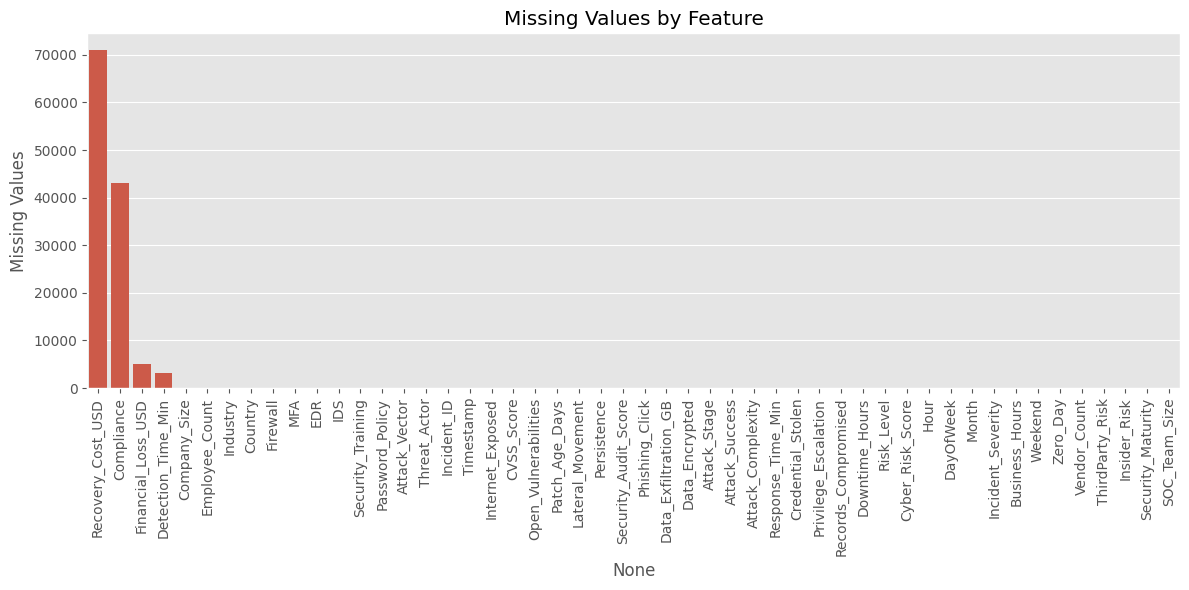

In [3]:
# ============================================================
# Missing Values Analysis
# ============================================================

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum()/len(df))*100,2)
})

missing = missing.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing)

plt.figure(figsize=(12,6))

sns.barplot(
    x=missing.index,
    y=missing["Missing Values"]
)

plt.xticks(rotation=90)
plt.title("Missing Values by Feature")
plt.tight_layout()

plt.show()

In [4]:
# ============================================================
# Duplicate Records
# ============================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates:,}")

duplicate_percentage = duplicates / len(df) * 100

print(f"Duplicate Percentage : {duplicate_percentage:.2f}%")

Duplicate Rows : 500
Duplicate Percentage : 0.50%


In [5]:
# ============================================================
# Memory Usage
# ============================================================

memory = df.memory_usage(deep=True).sum() / 1024**2

print(f"Dataset Memory Usage : {memory:.2f} MB")

Dataset Memory Usage : 103.43 MB


In [6]:
# ============================================================
# Numerical Summary
# ============================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Incident_ID,100500.00,50001.76,28868.95,1.00,25003.75,50004.50,75007.25,100000.00
Employee_Count,100500.00,2108.61,3654.10,20.00,134.00,250.00,1711.00,14999.00
Firewall,100500.00,0.92,0.27,0.00,1.00,1.00,1.00,1.00
MFA,100500.00,0.75,0.43,0.00,1.00,1.00,1.00,1.00
EDR,100500.00,0.80,0.40,0.00,1.00,1.00,1.00,1.00
...,...,...,...,...,...,...,...,...
Vendor_Count,100500.00,23.30,30.15,1.00,6.00,10.00,22.00,100.00
ThirdParty_Risk,100500.00,34.00,19.73,0.00,21.40,28.40,38.30,100.00
Insider_Risk,100500.00,26.09,20.29,0.00,10.20,16.50,46.70,93.50
Security_Maturity,100500.00,77.82,18.29,0.00,60.00,80.00,100.00,100.00


In [7]:
# ============================================================
# Categorical Summary
# ============================================================

display(df.describe(include="object").T)

,count,unique,top,freq
Timestamp,100500,100000,2023-01-06 23:45:00,2
Industry,100500,8,Banking,18107
Country,100500,8,UK,12729
Company_Size,100500,3,Small,50246
Attack_Vector,100500,7,Email,35299
Threat_Actor,100500,5,Cyber Criminal,45073
Password_Policy,100500,3,Moderate,45308
Attack_Stage,100500,5,Reconnaissance,57567
Attack_Complexity,100500,3,Intermediate,55180
Risk_Level,100500,4,Medium,51262


In [8]:
# ============================================================
# Unique Values
# ============================================================

unique = pd.DataFrame({
    "Unique Values": df.nunique()
})

display(unique.sort_values(
    by="Unique Values",
    ascending=False
))

,Unique Values
Incident_ID,100000
Timestamp,100000
Cyber_Risk_Score,99589
Financial_Loss_USD,93250
Recovery_Cost_USD,29354
...,...
Phishing_Click,2
Privilege_Escalation,2
Business_Hours,2
Weekend,2


In [9]:
# ============================================================
# Separate Numerical and Categorical Columns
# ============================================================

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numerical Features   : {len(numerical_columns)}")
print(f"Categorical Features : {len(categorical_columns)}")

Numerical Features   : 36
Categorical Features : 14


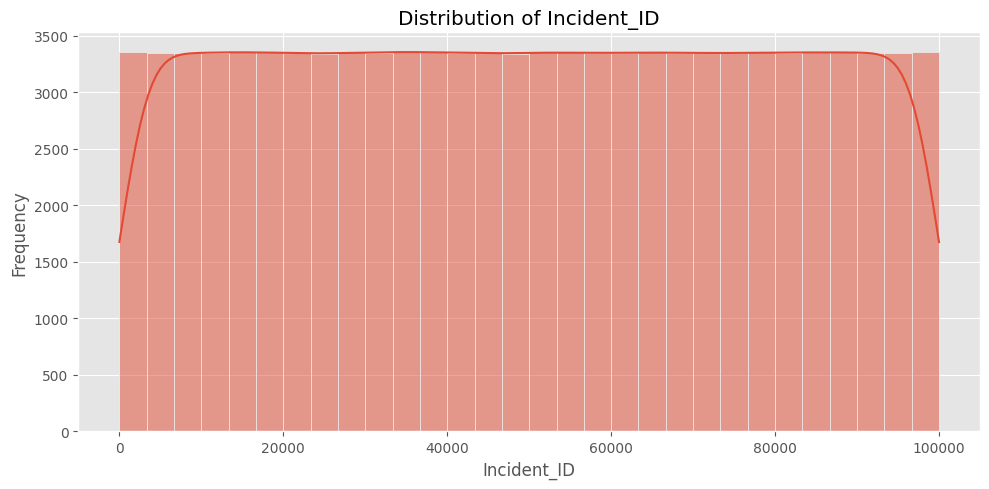

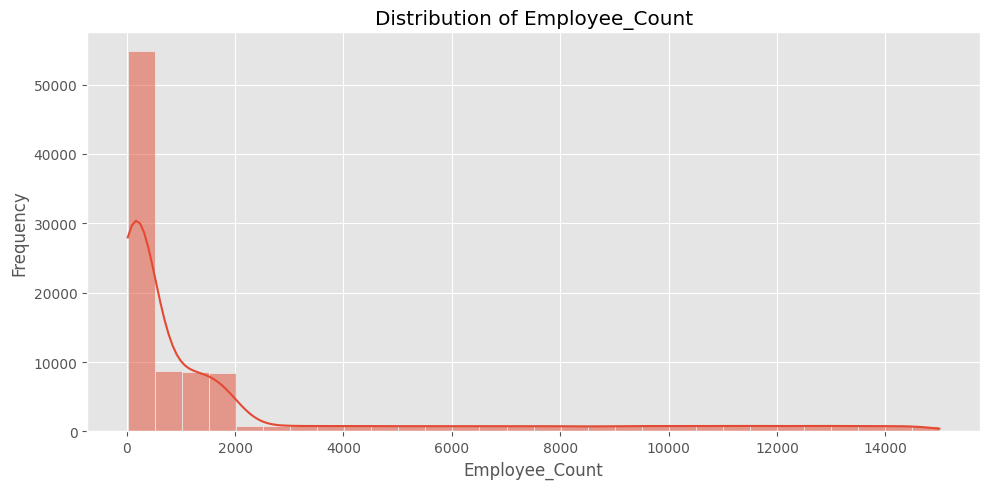

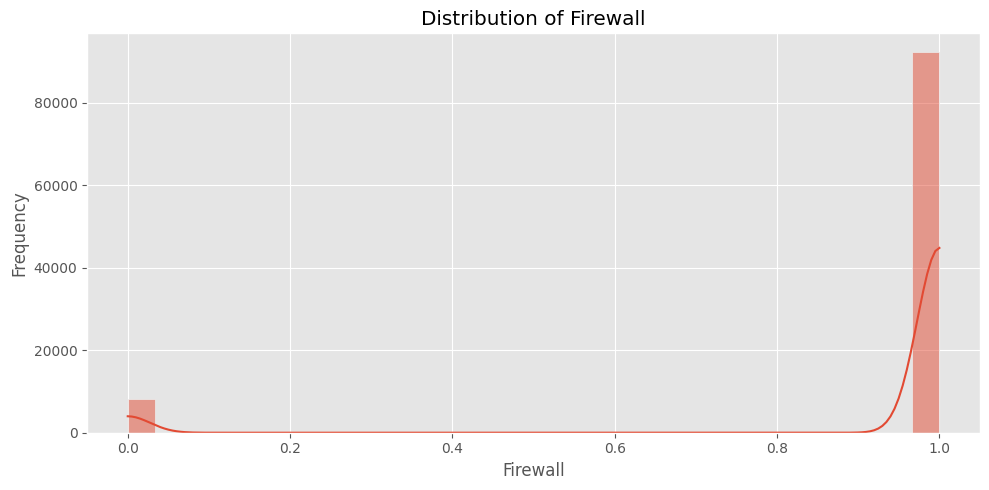

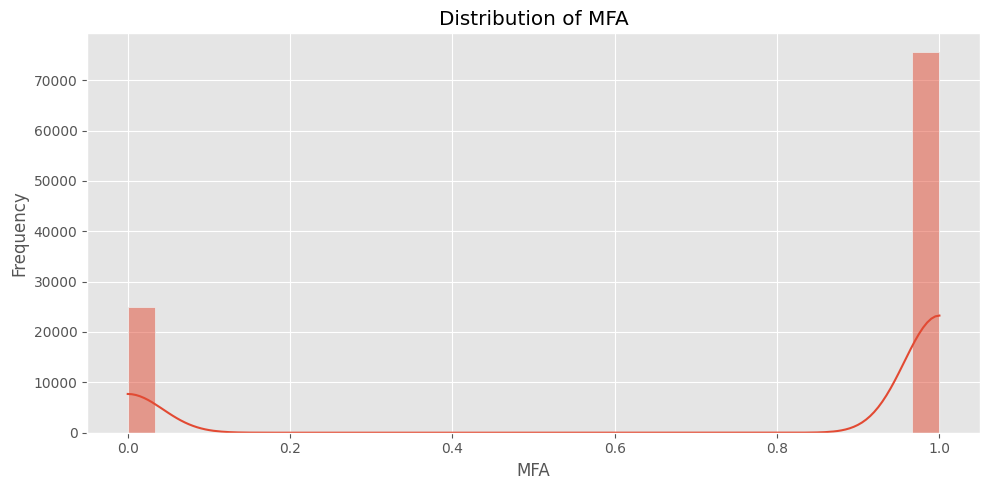

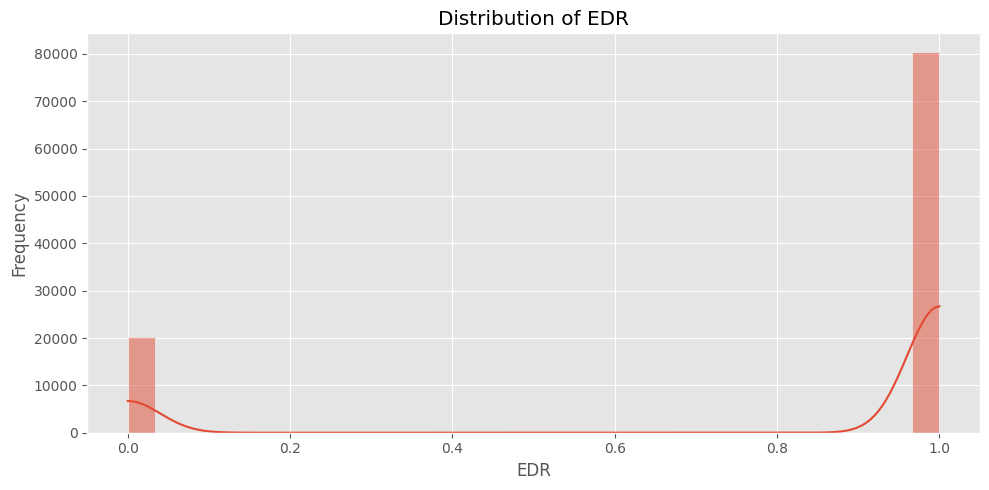

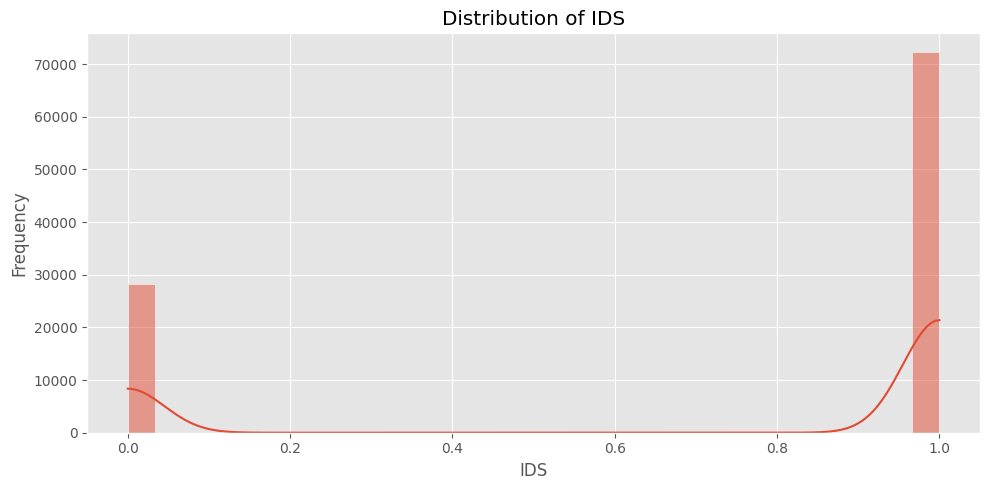

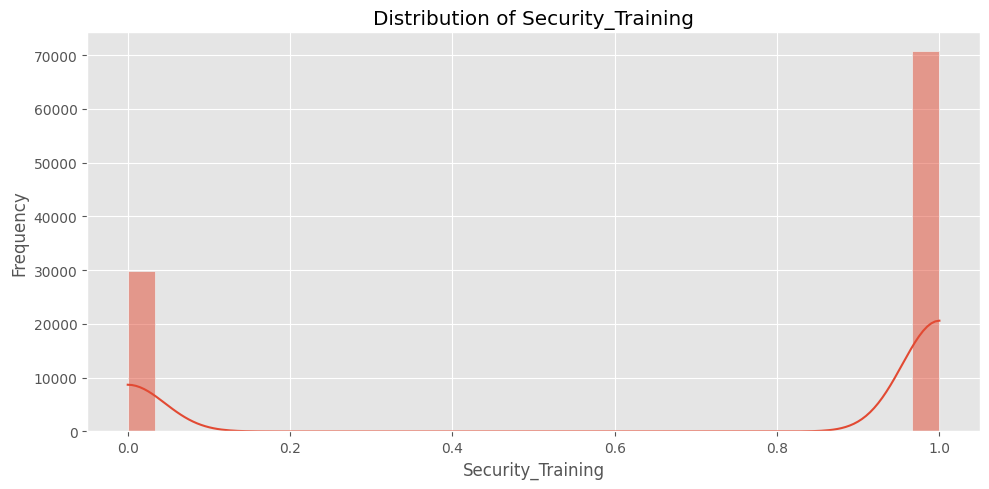

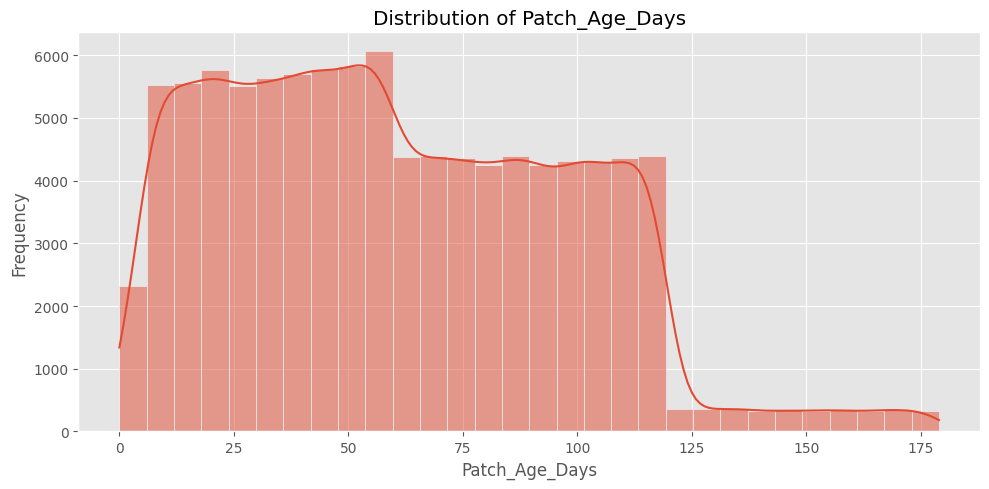

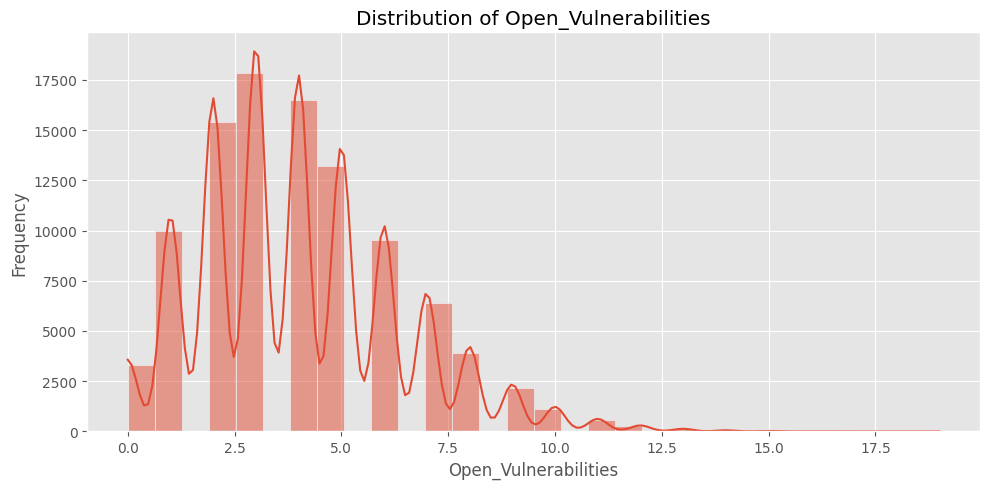

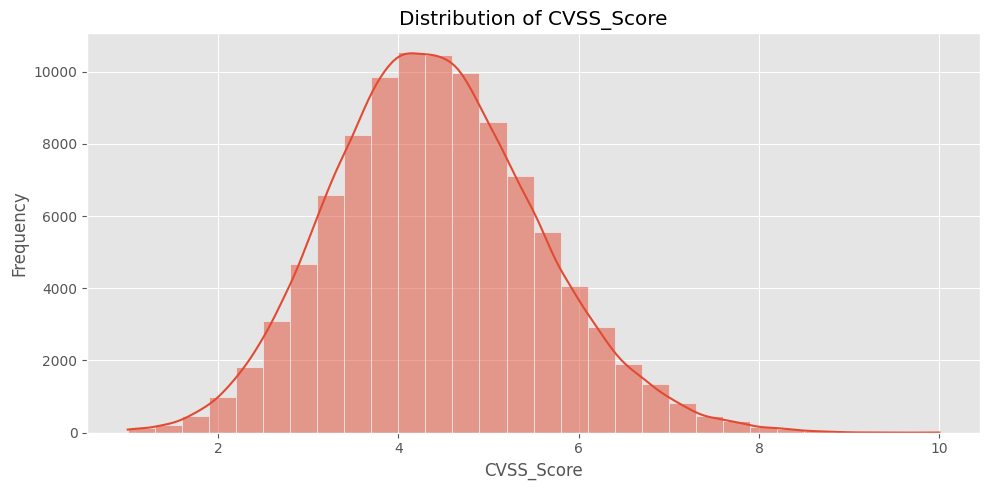

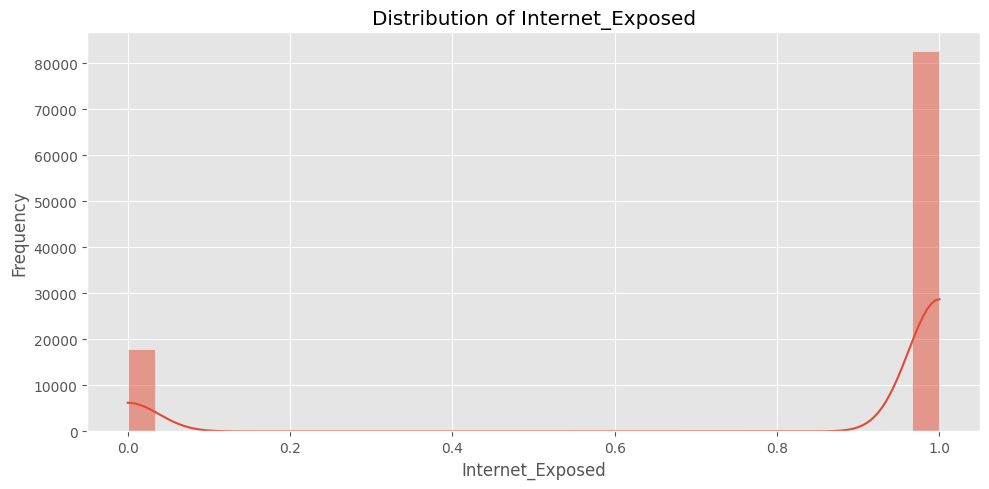

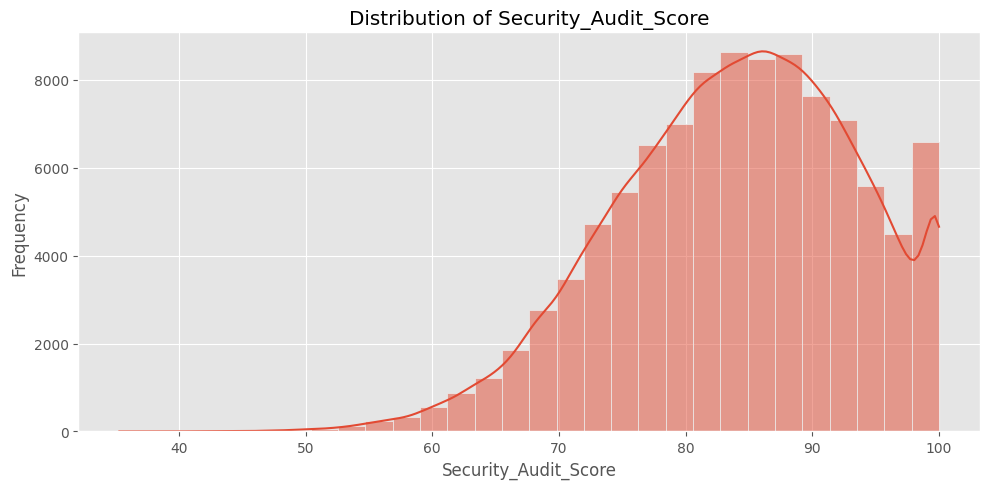

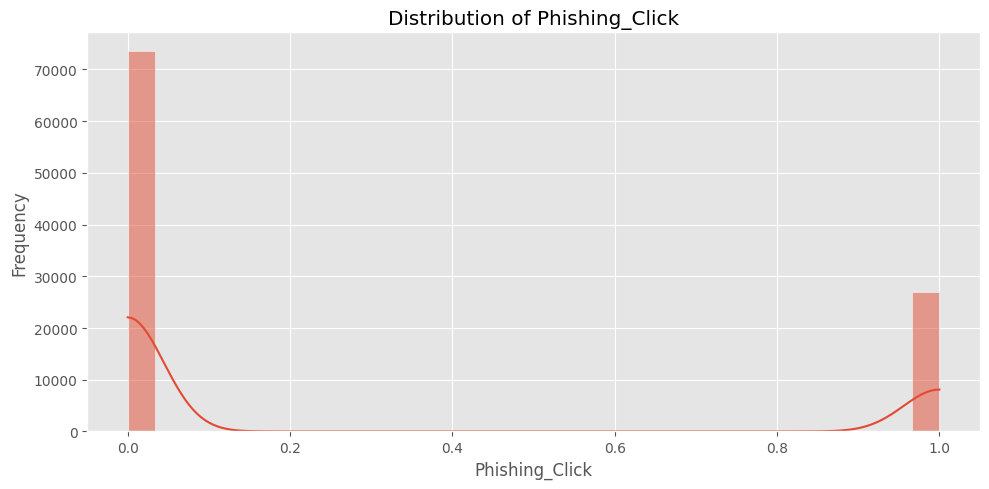

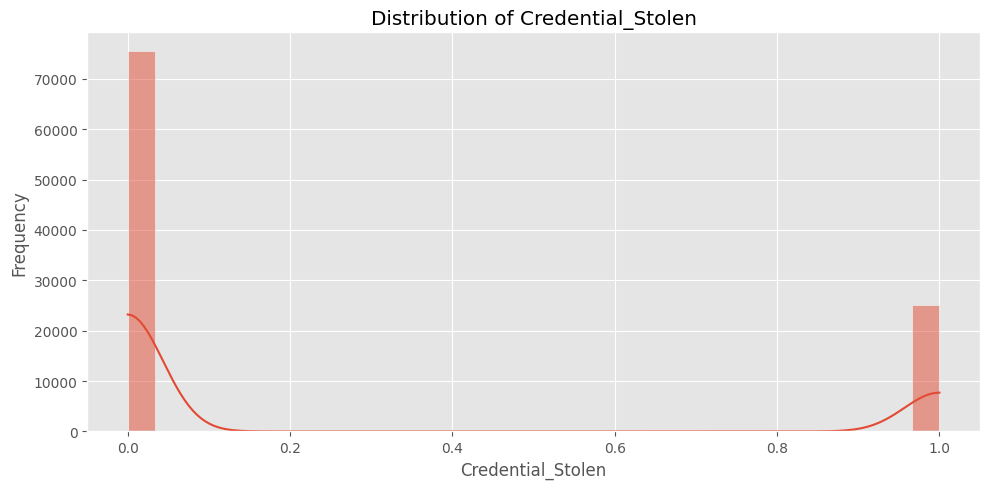

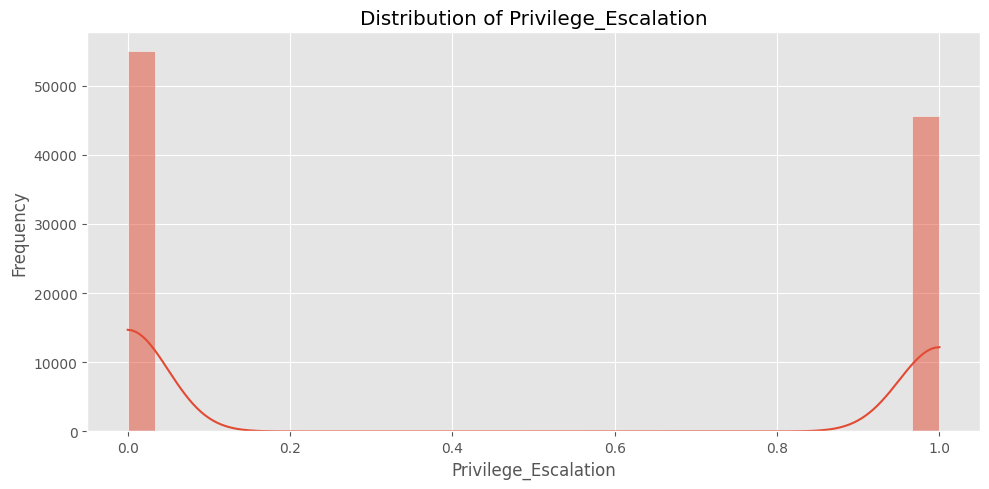

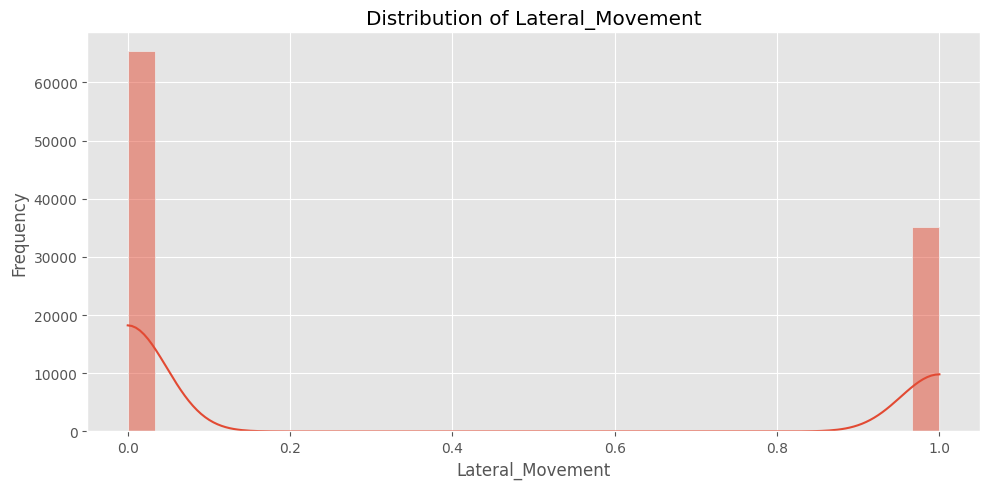

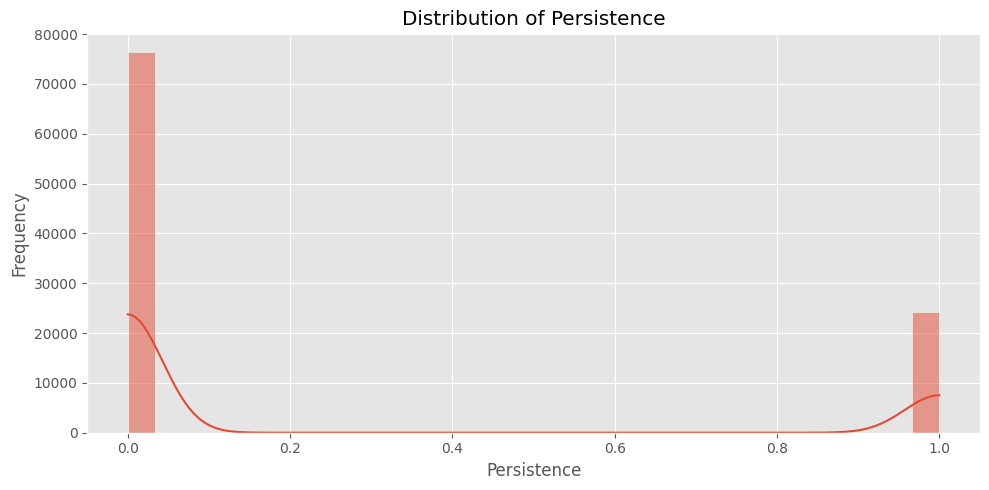

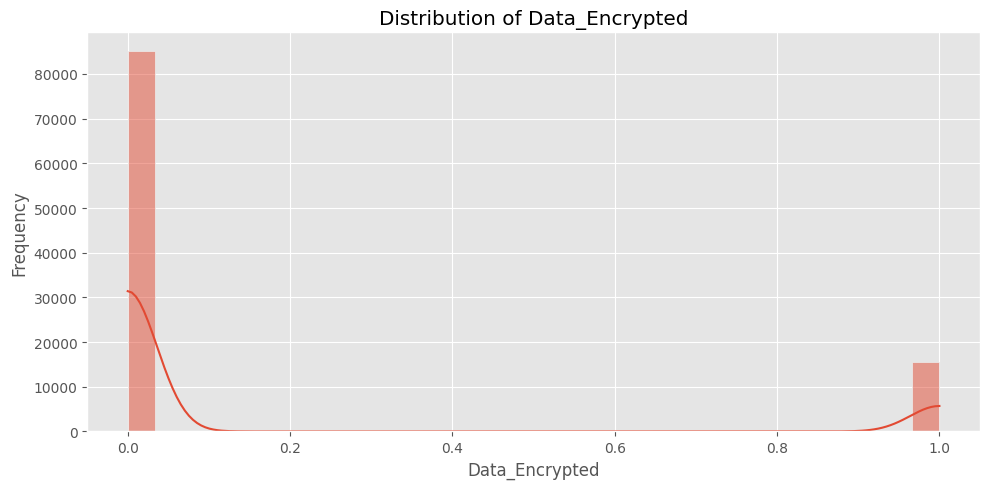

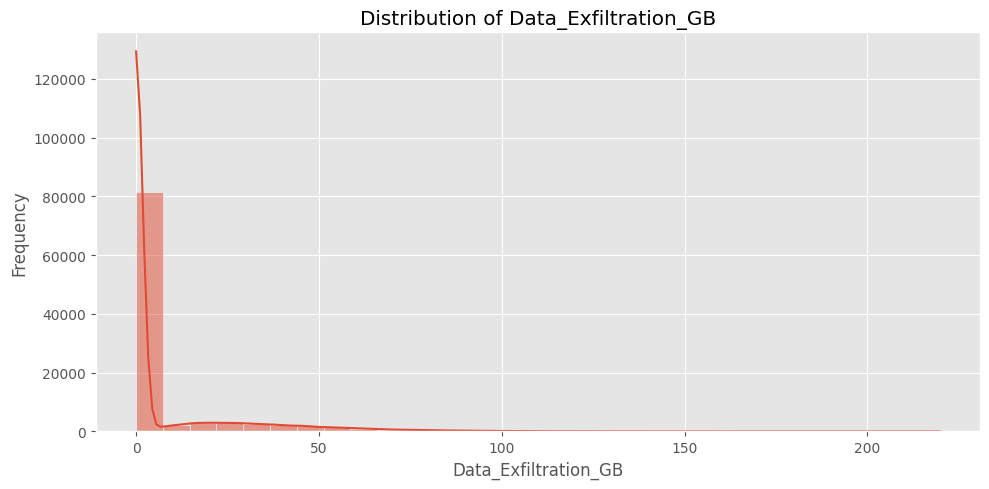

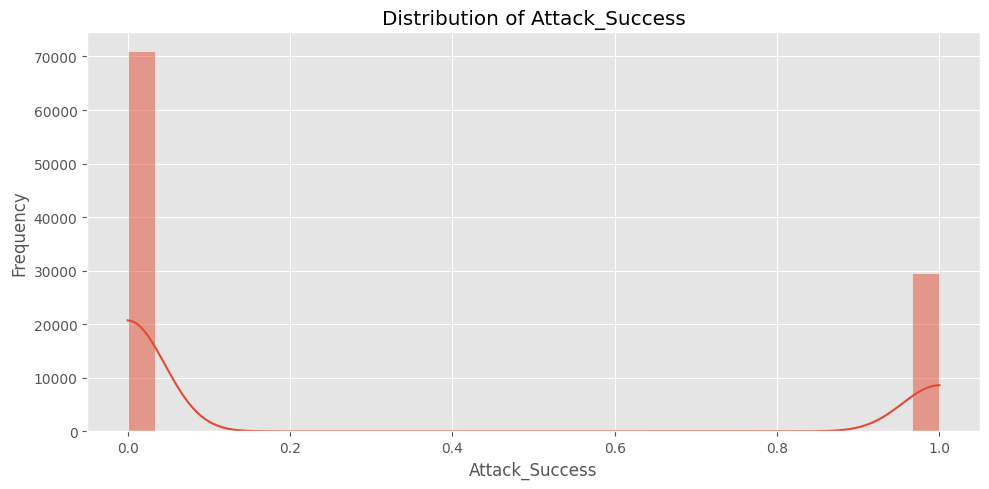

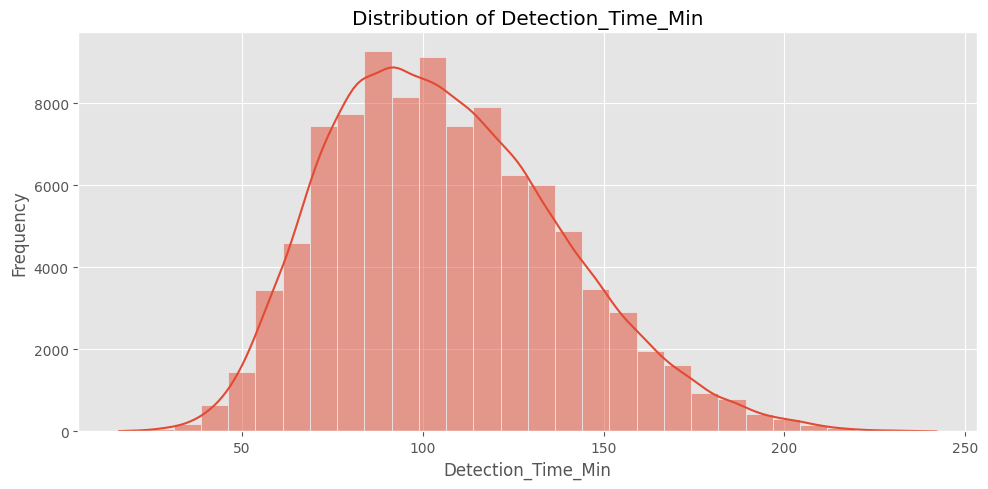

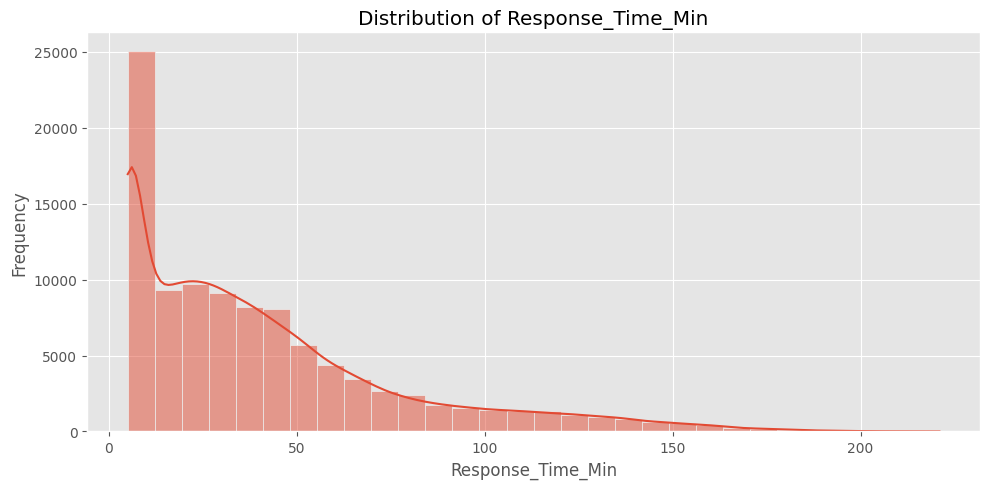

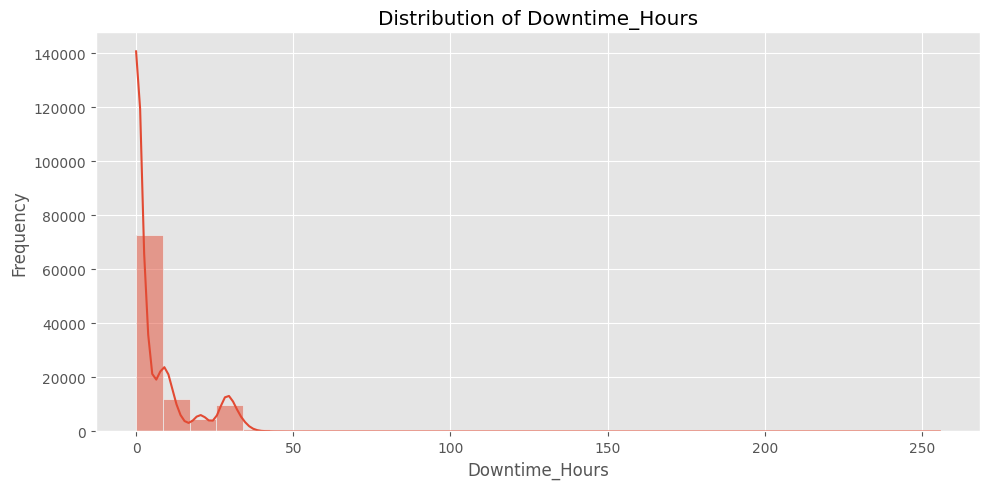

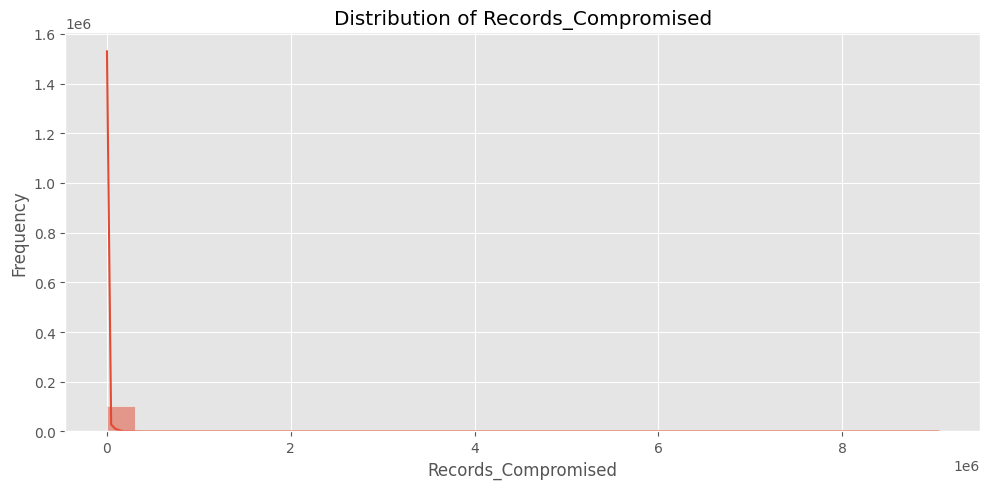

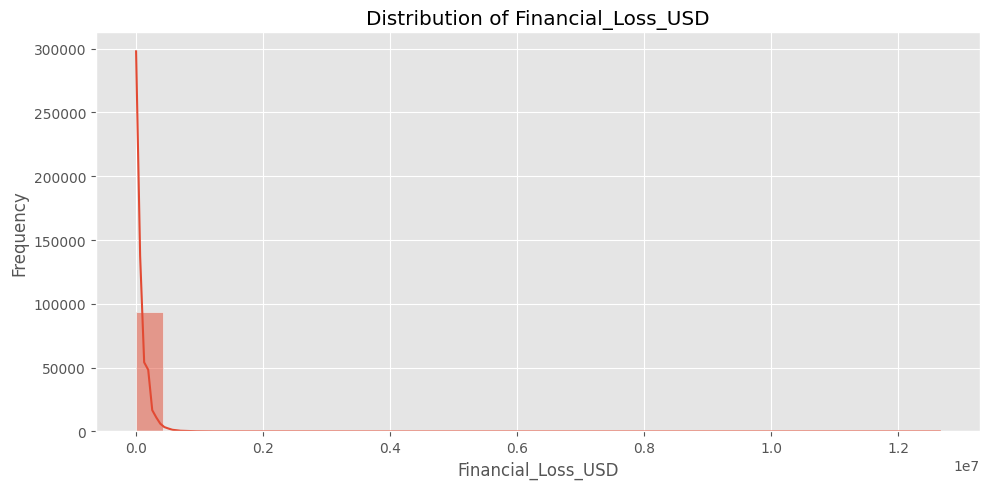

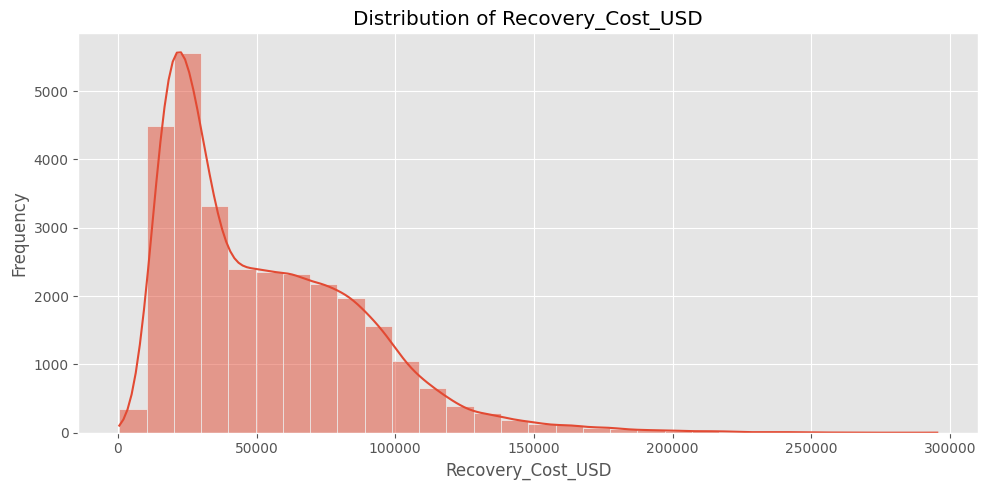

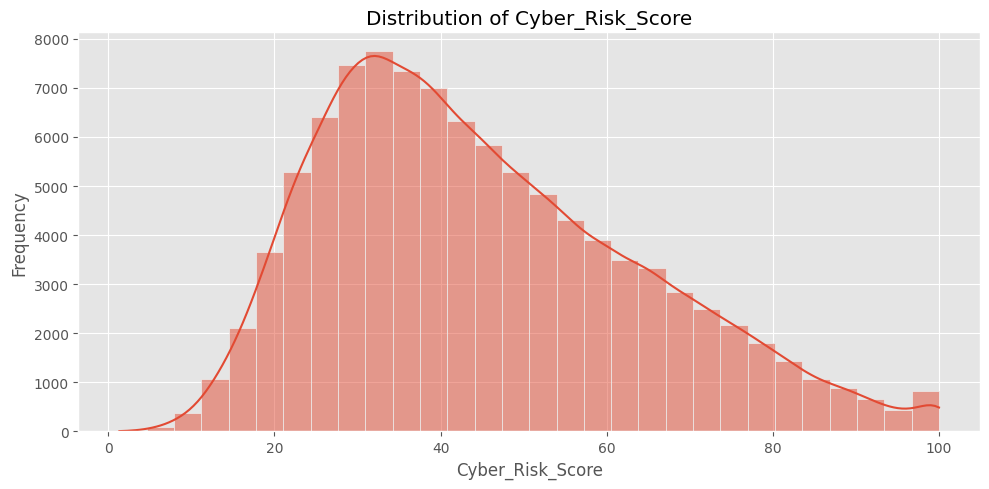

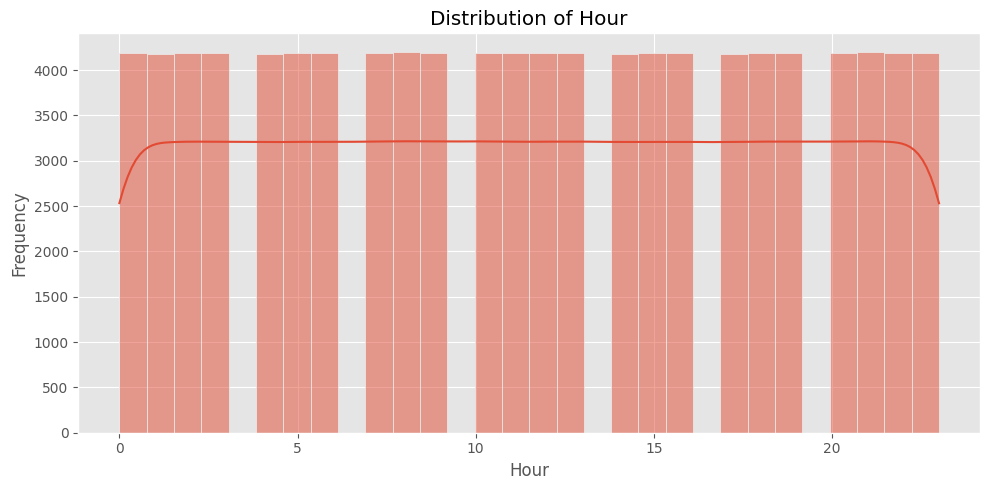

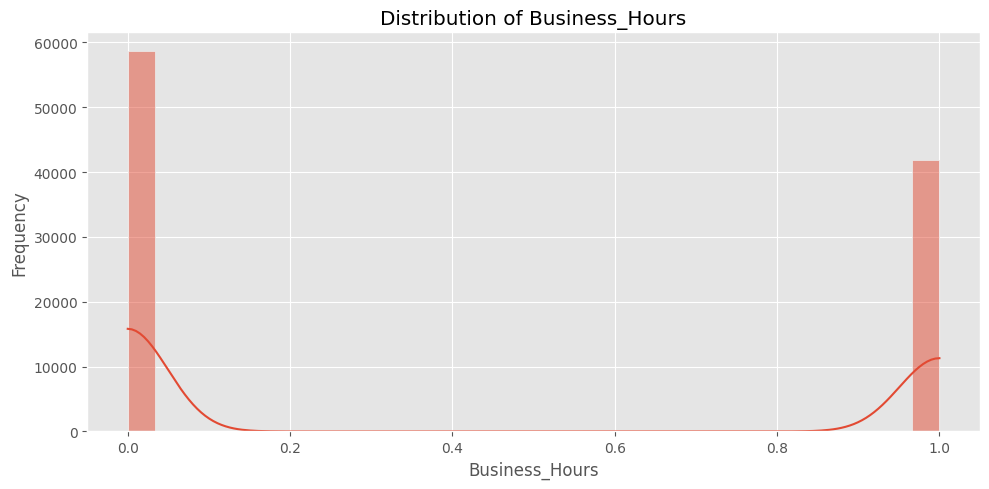

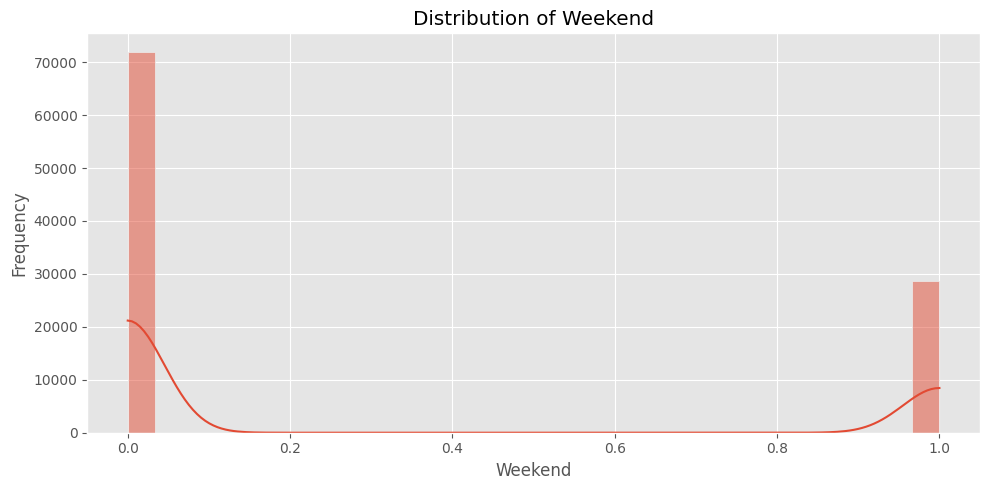

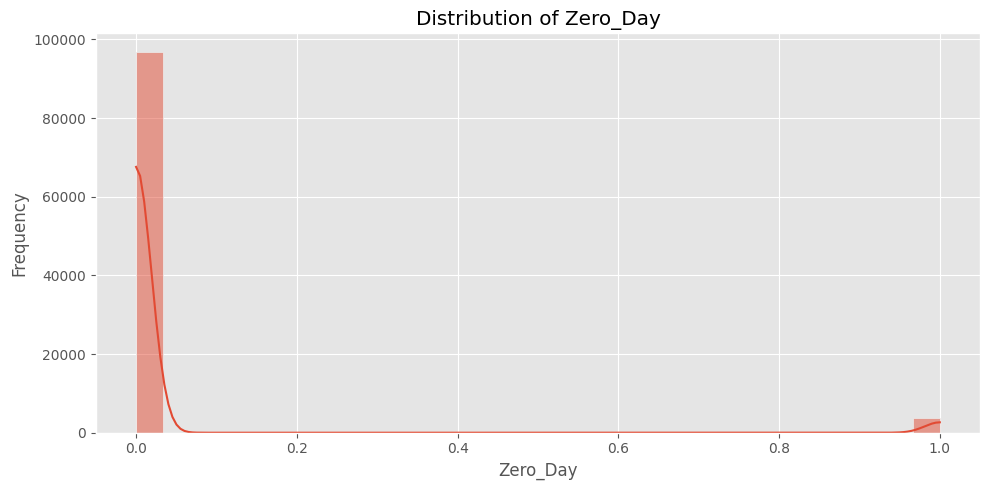

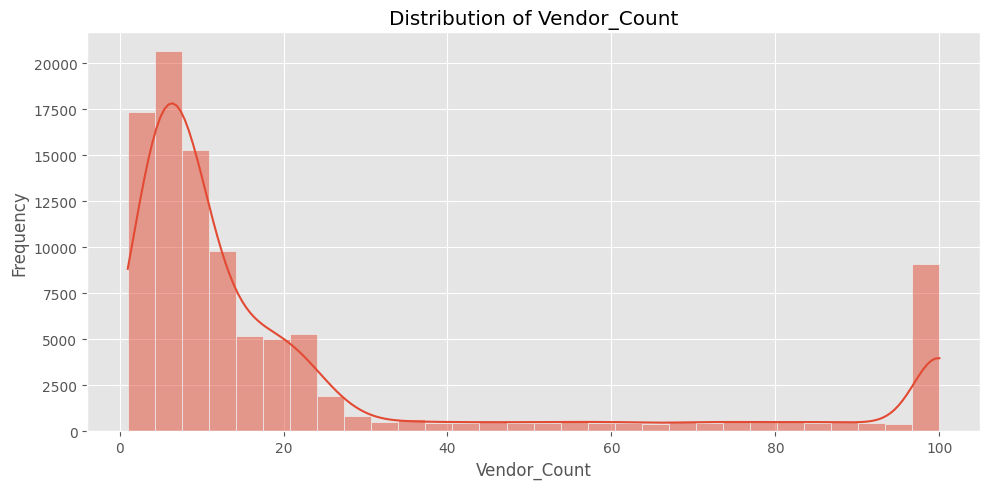

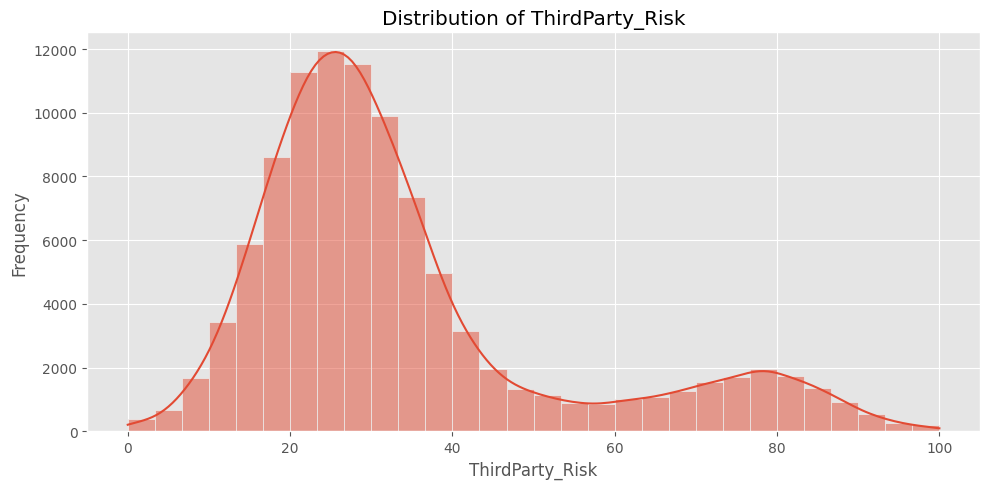

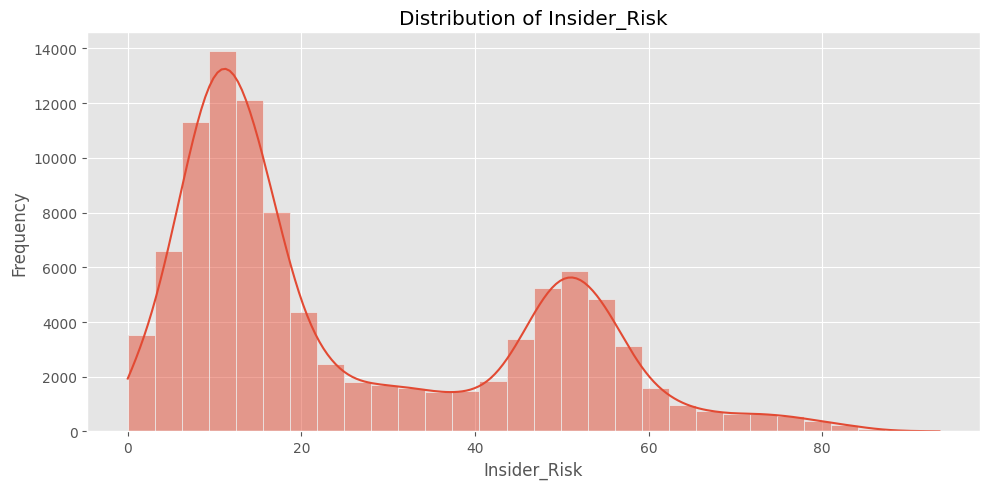

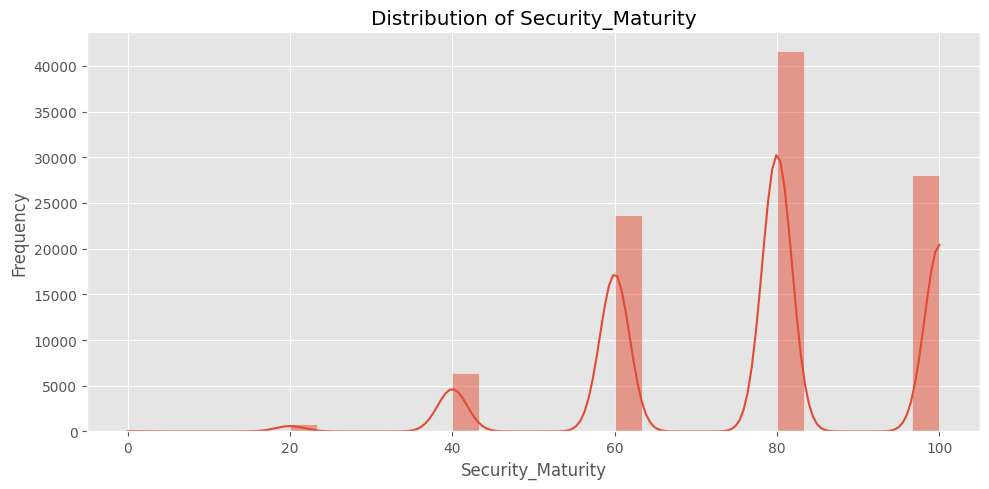

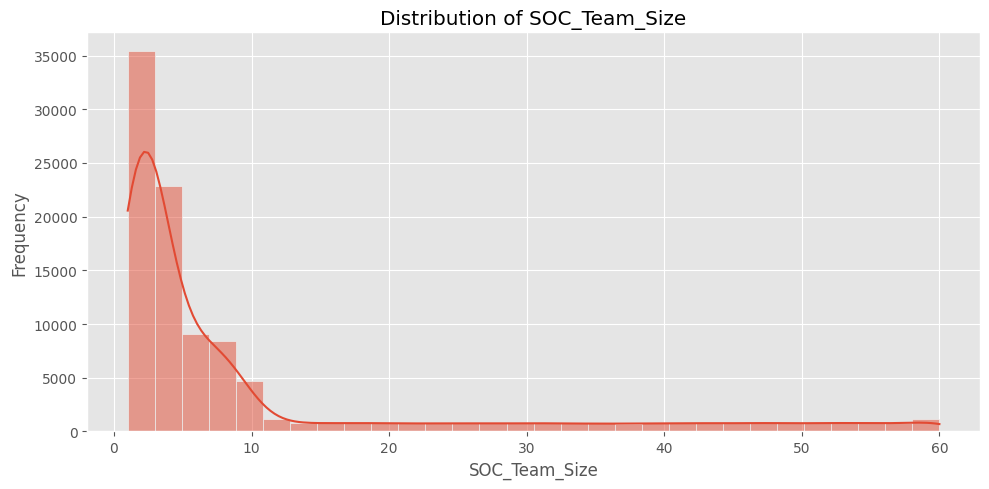

In [10]:
# ============================================================
# Numerical Feature Distribution
# ============================================================

for column in numerical_columns:

    plt.figure(figsize=(10,5))

    sns.histplot(
        df[column],
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {column}")

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.show()

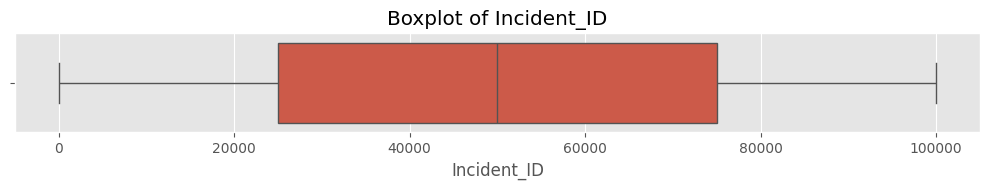

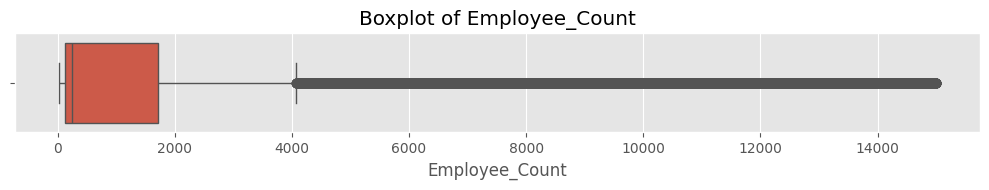

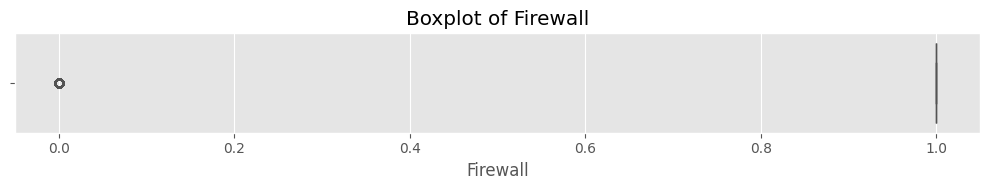

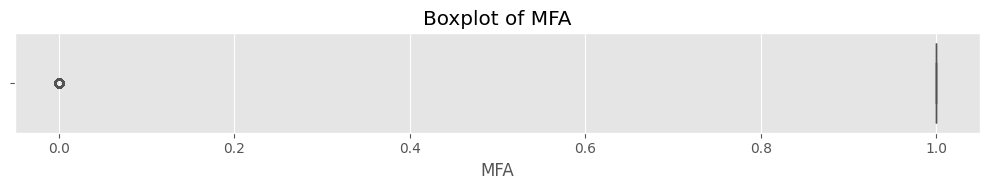

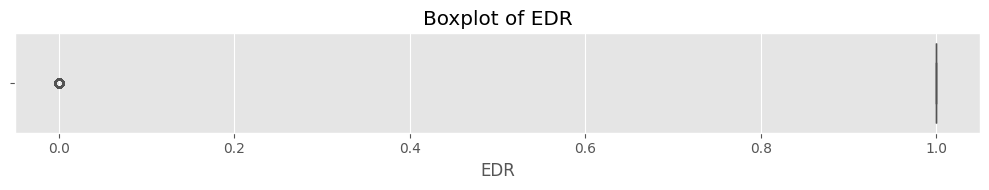

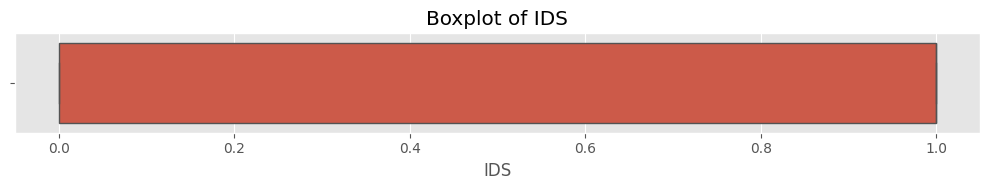

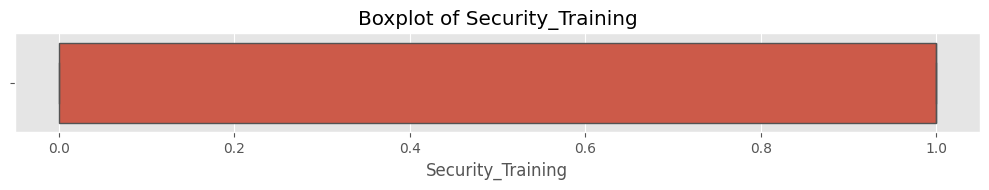

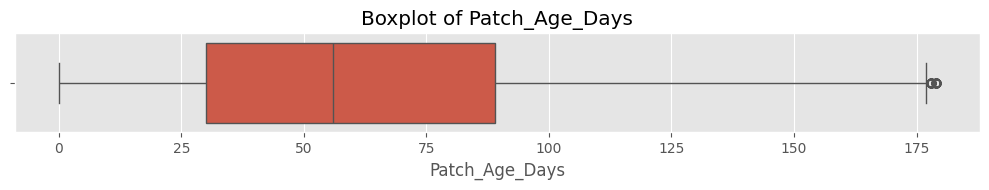

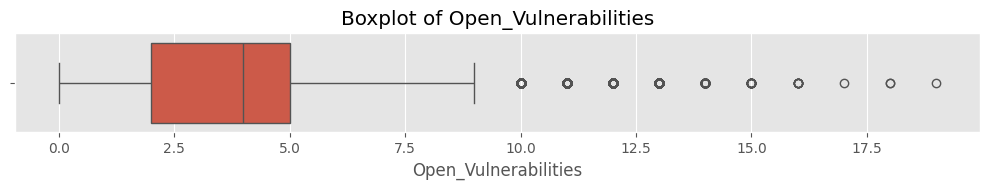

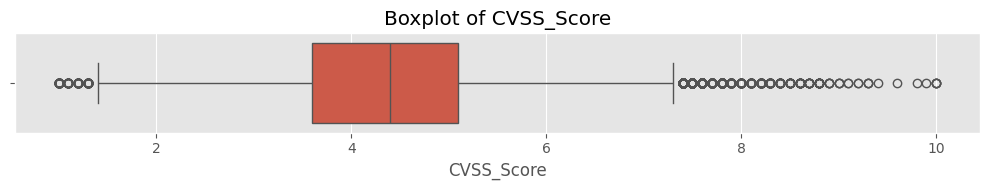

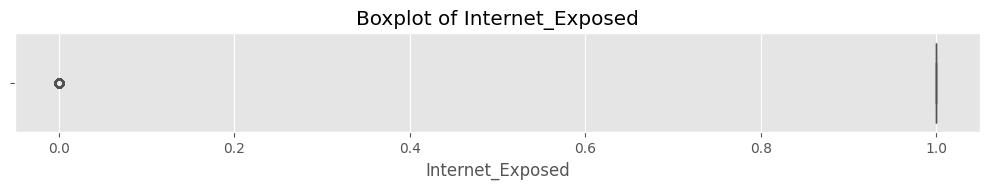

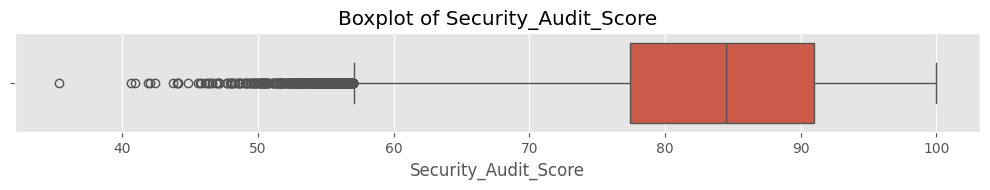

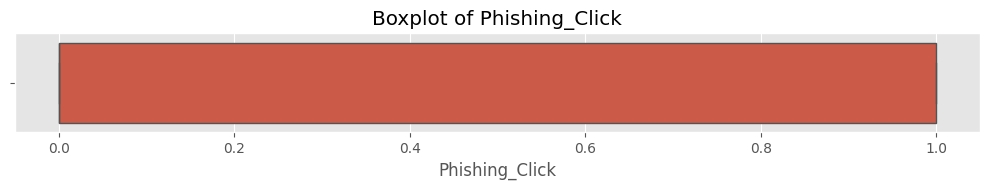

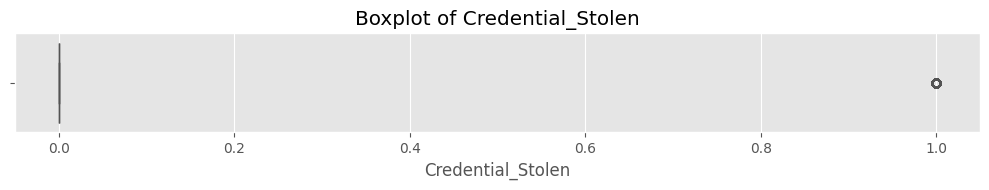

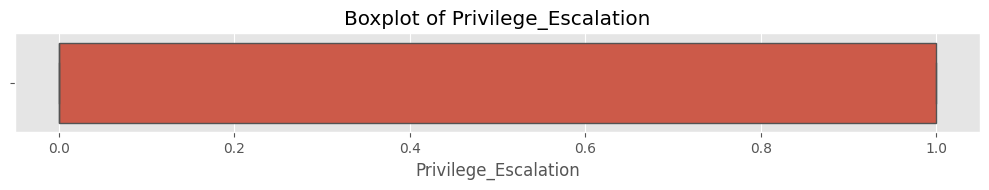

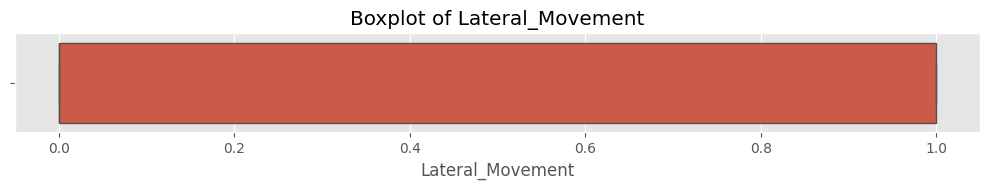

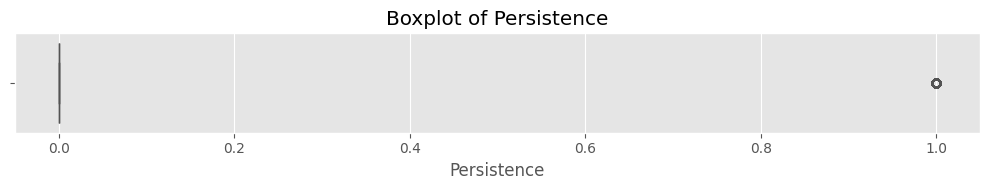

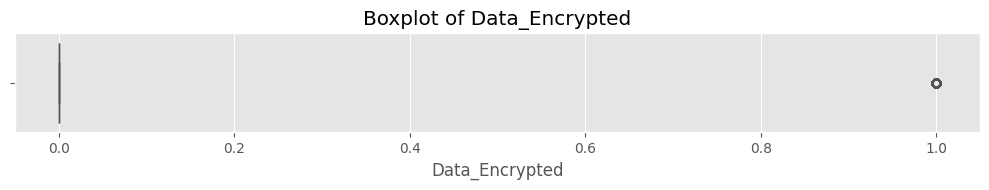

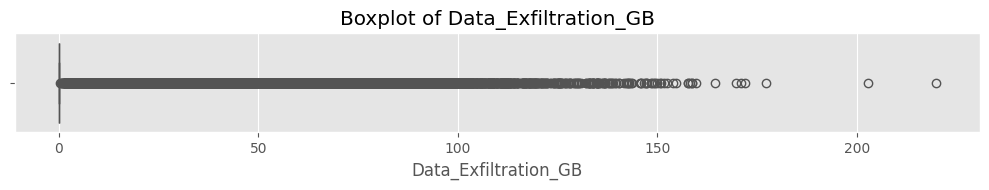

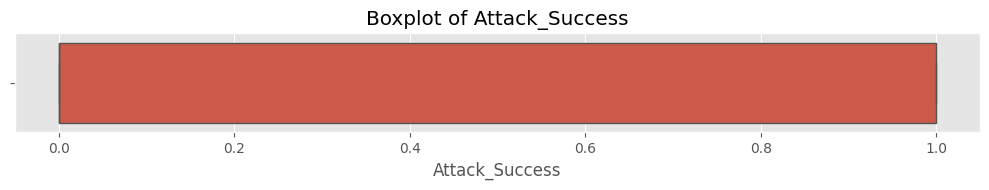

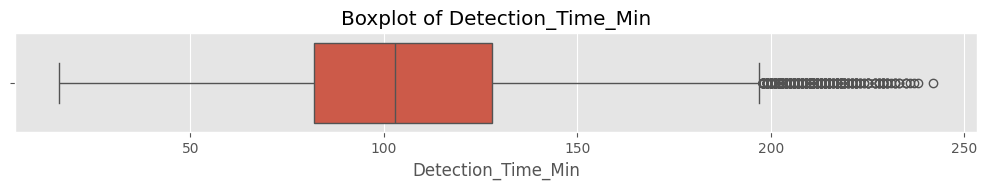

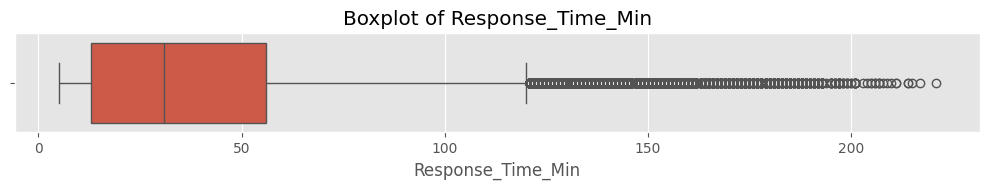

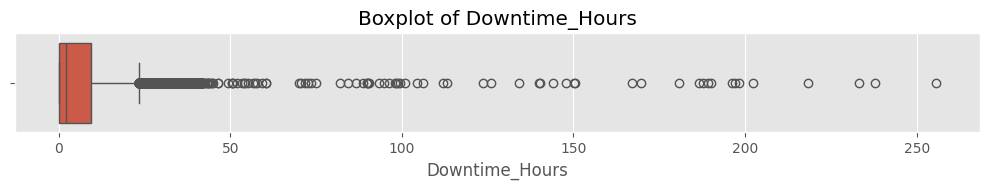

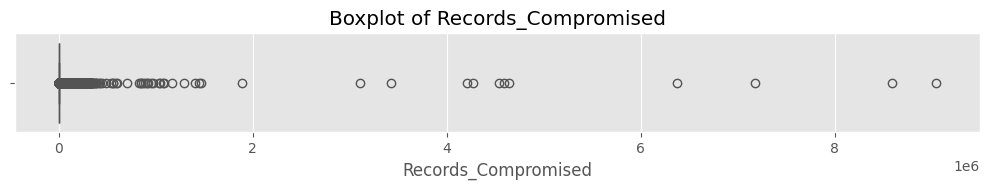

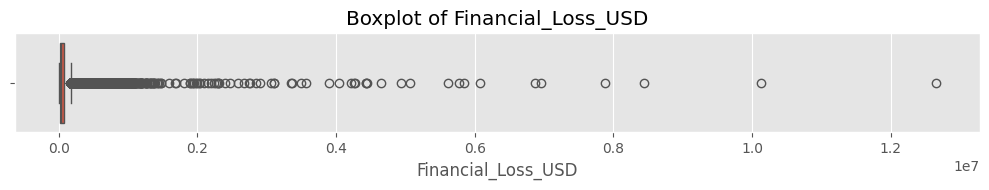

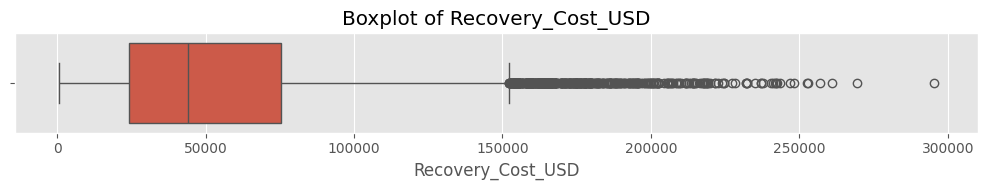

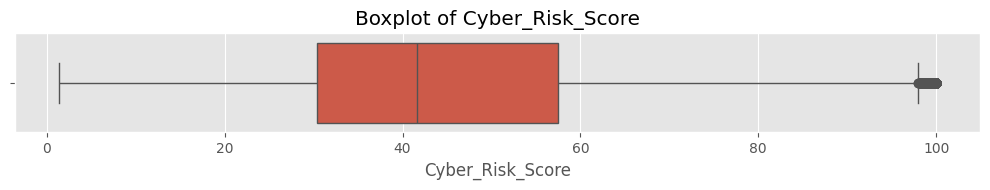

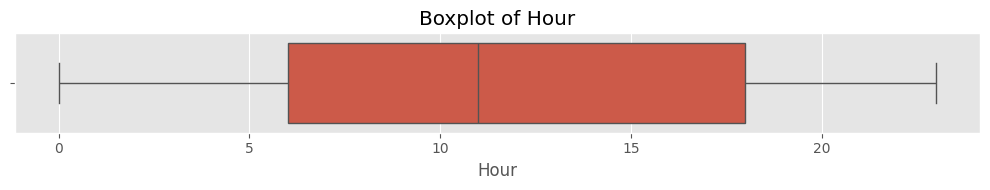

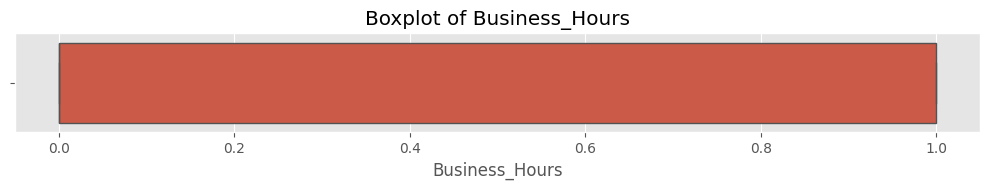

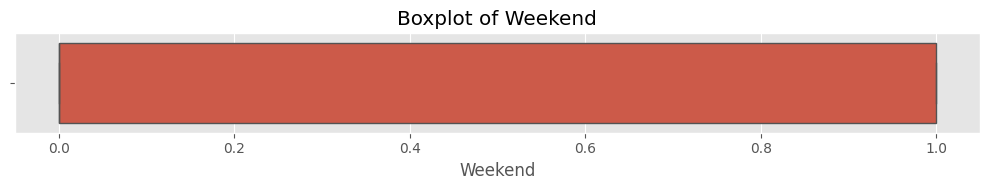

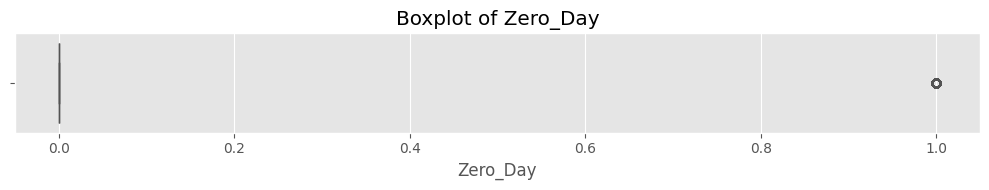

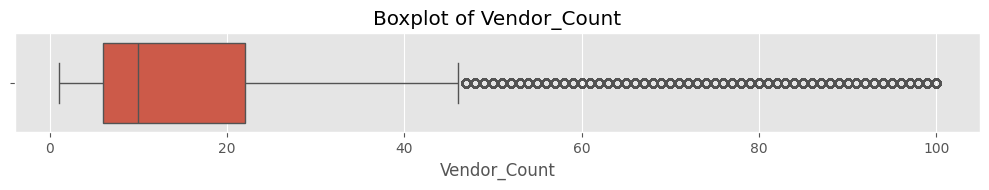

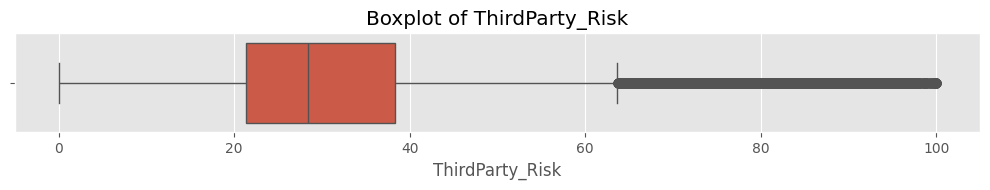

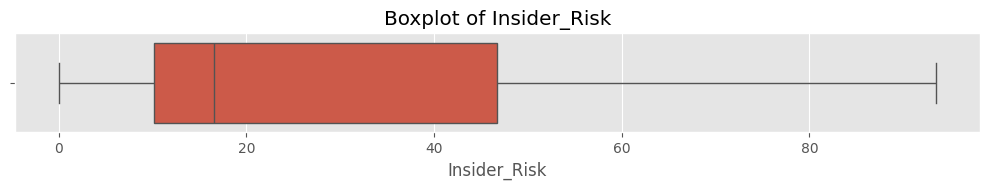

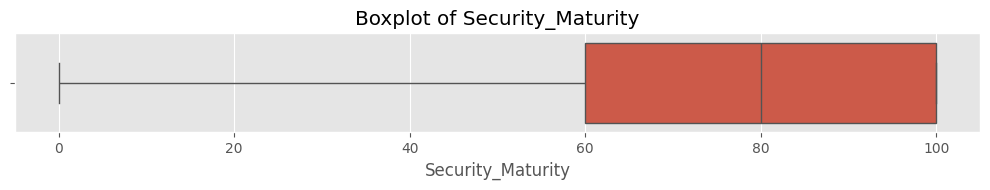

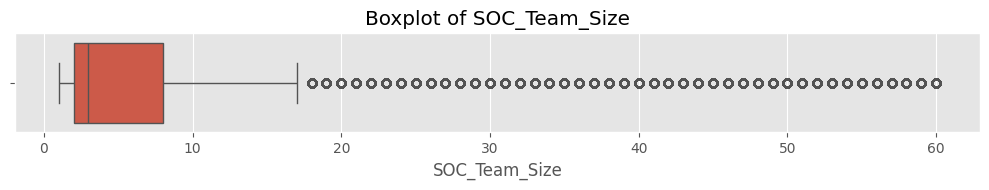

In [11]:
# ============================================================
# Boxplots for Numerical Features
# ============================================================

for column in numerical_columns:

    plt.figure(figsize=(10,2))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Boxplot of {column}")

    plt.tight_layout()

    plt.show()

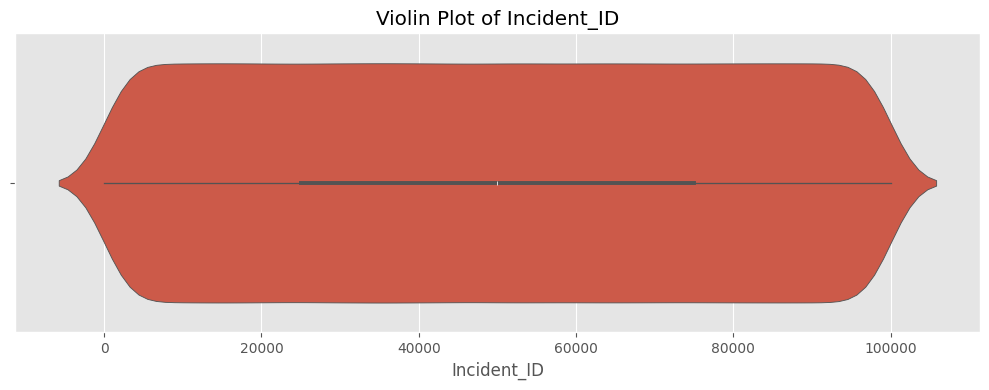

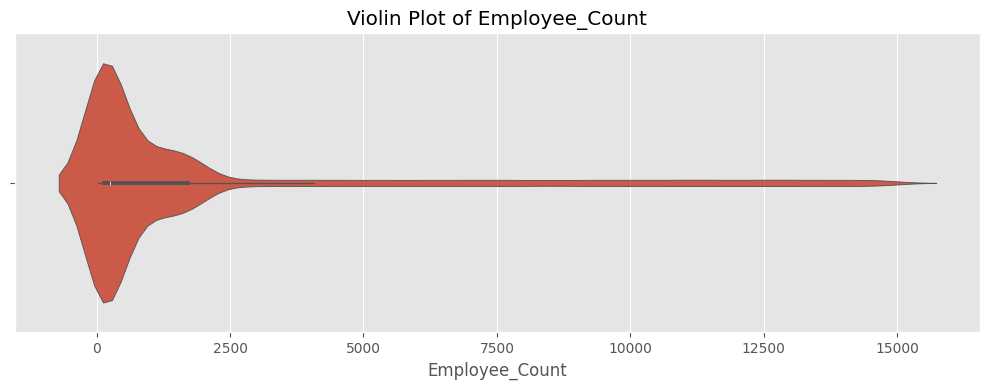

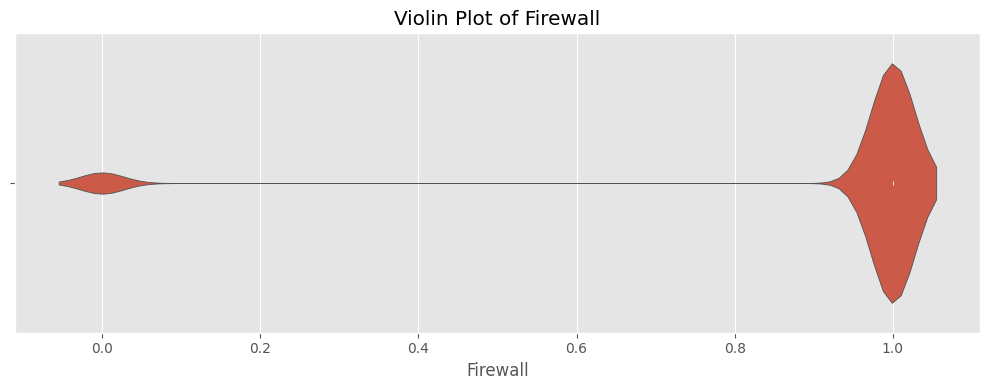

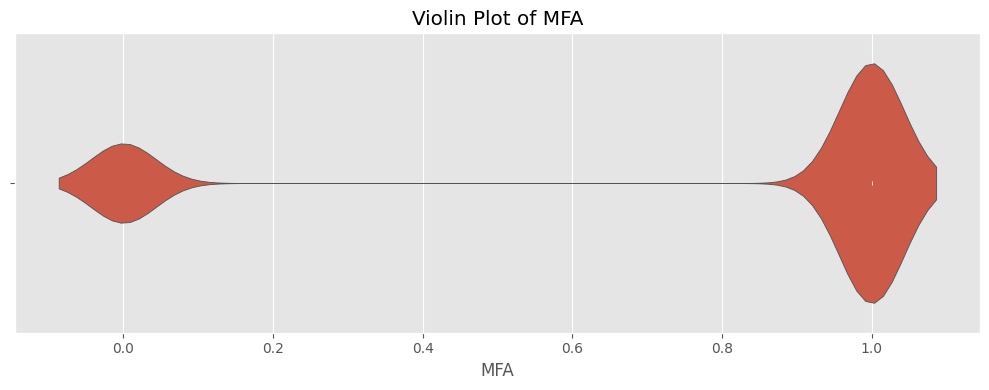

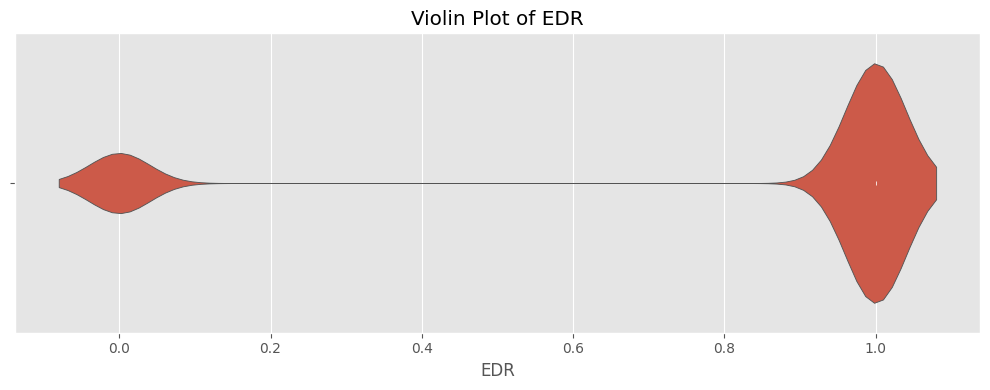

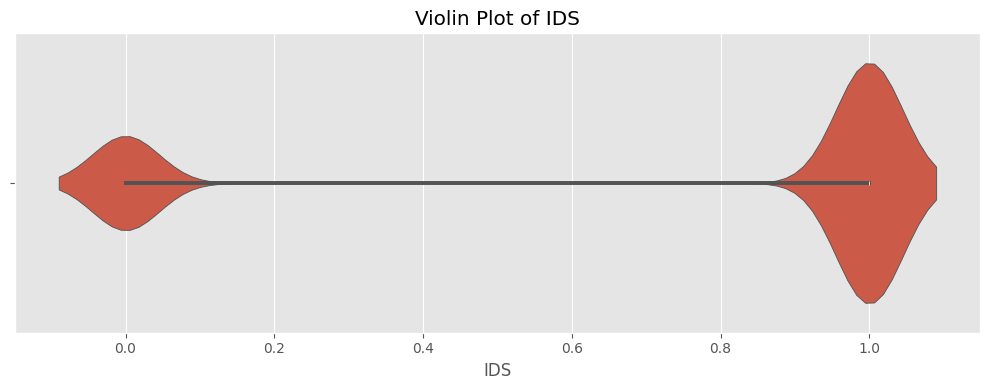

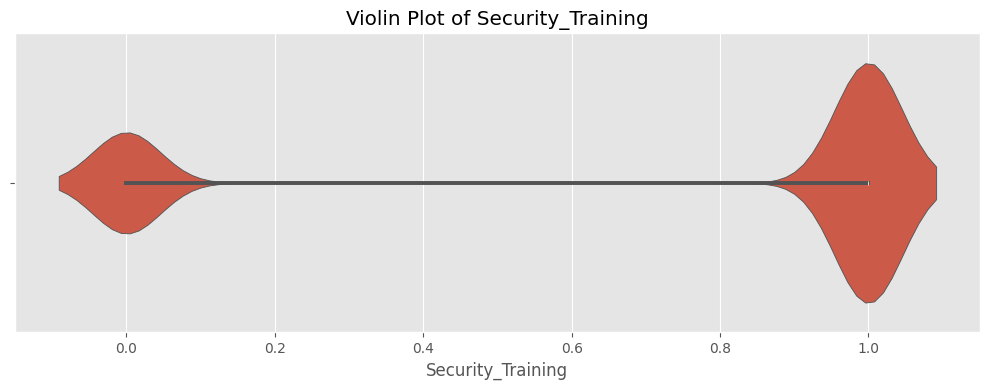

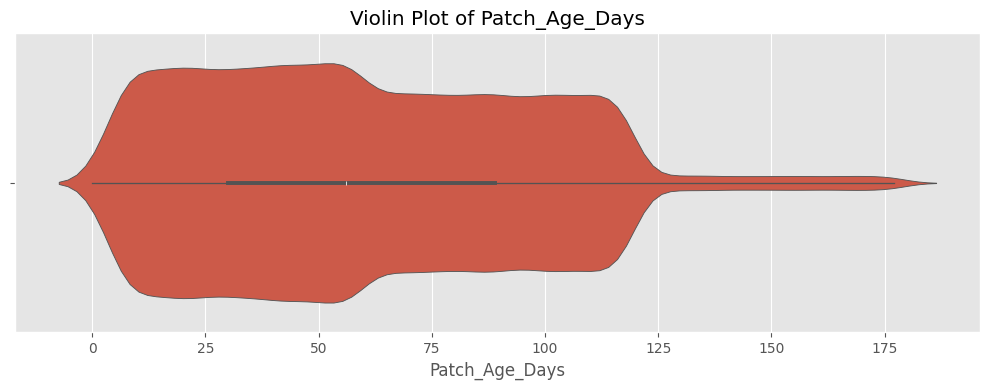

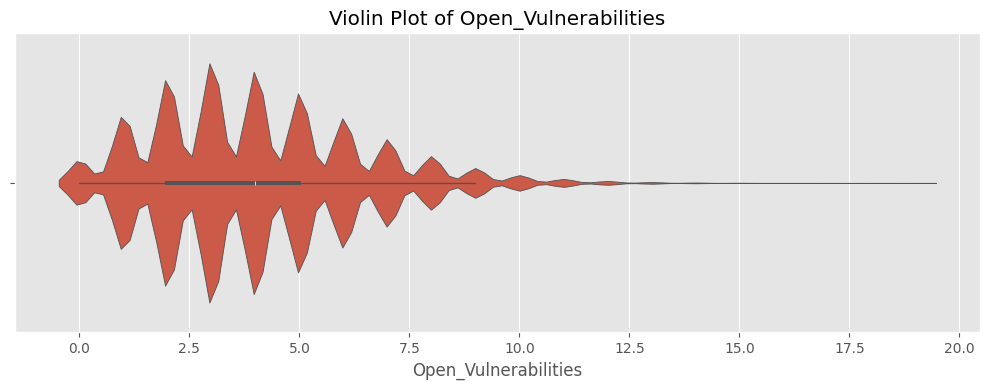

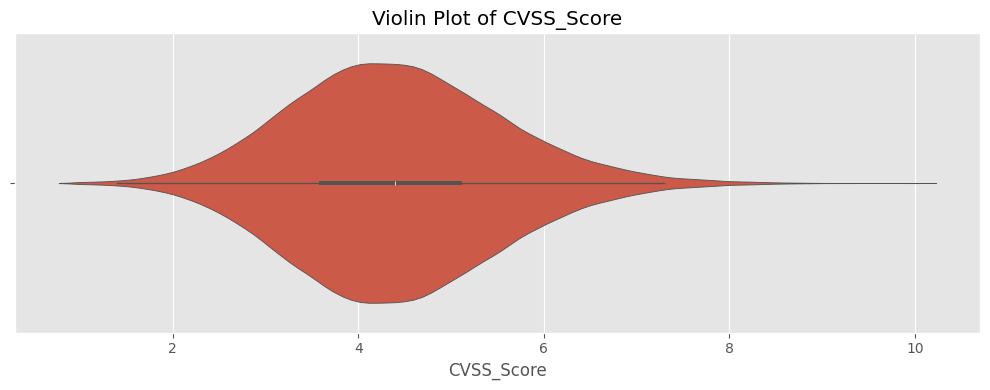

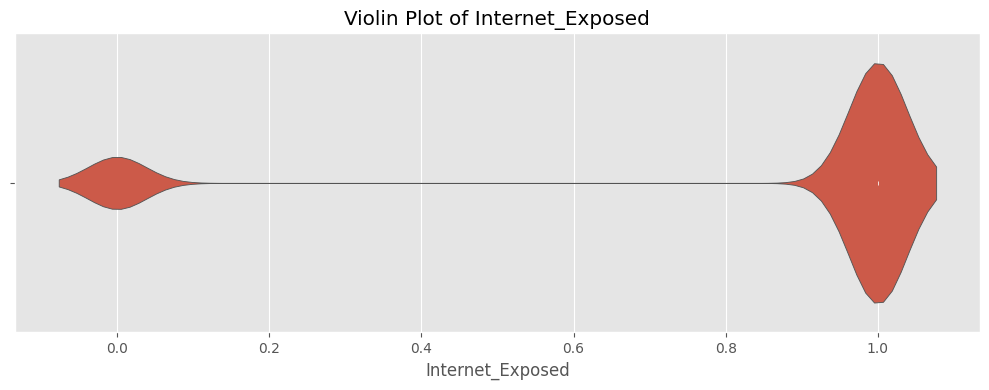

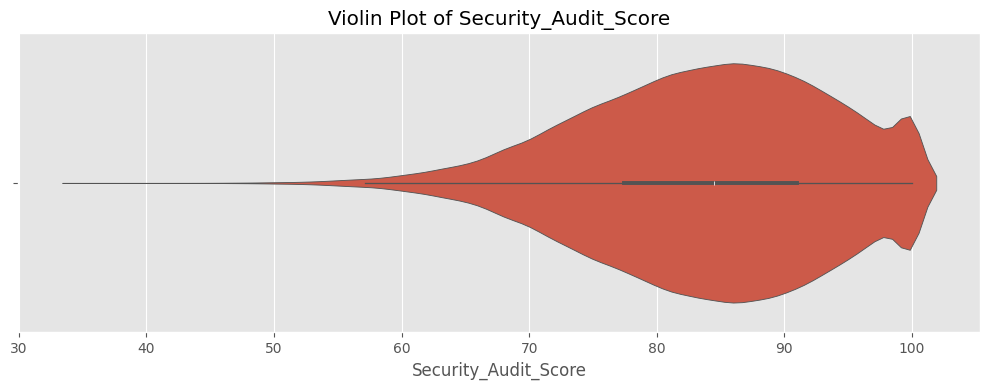

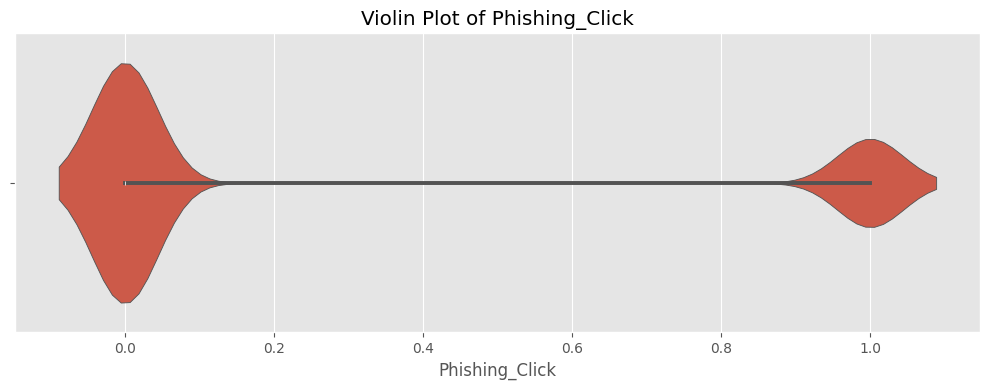

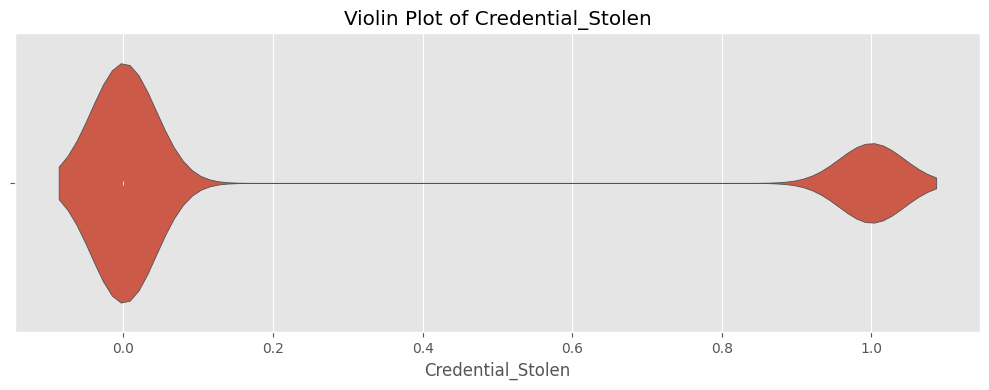

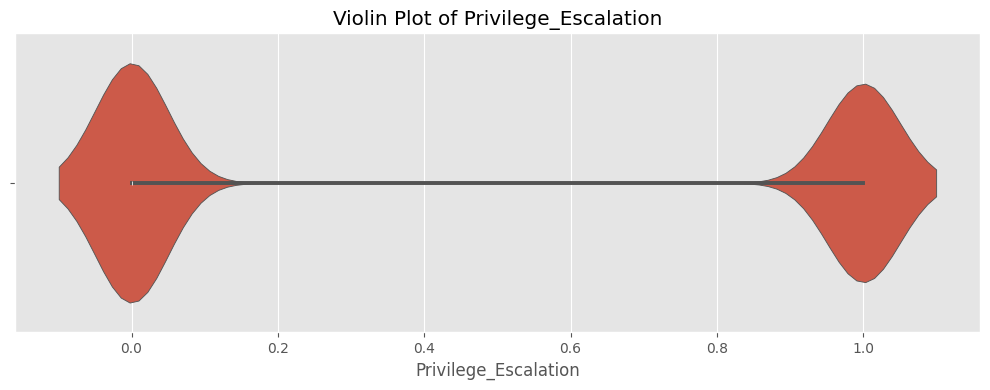

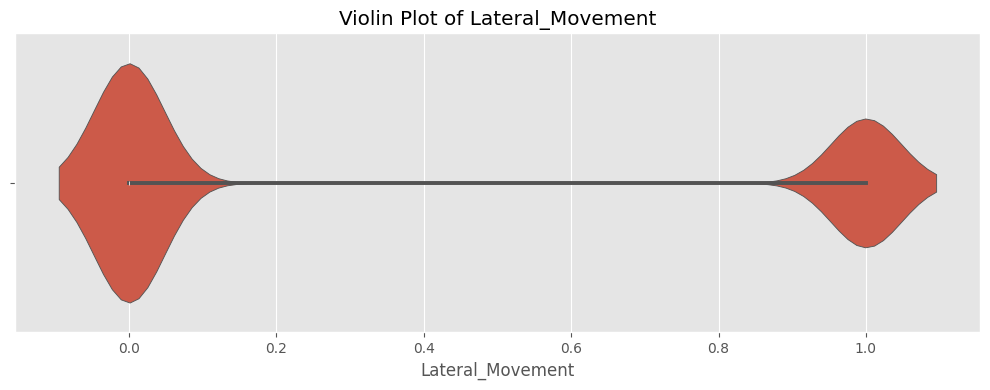

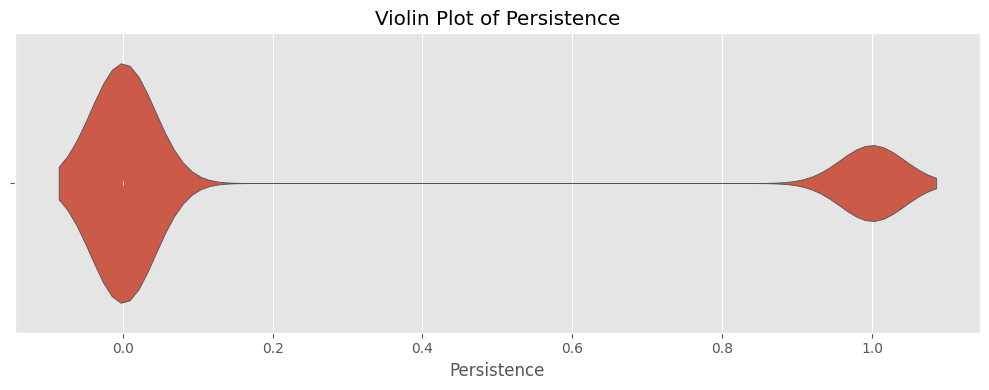

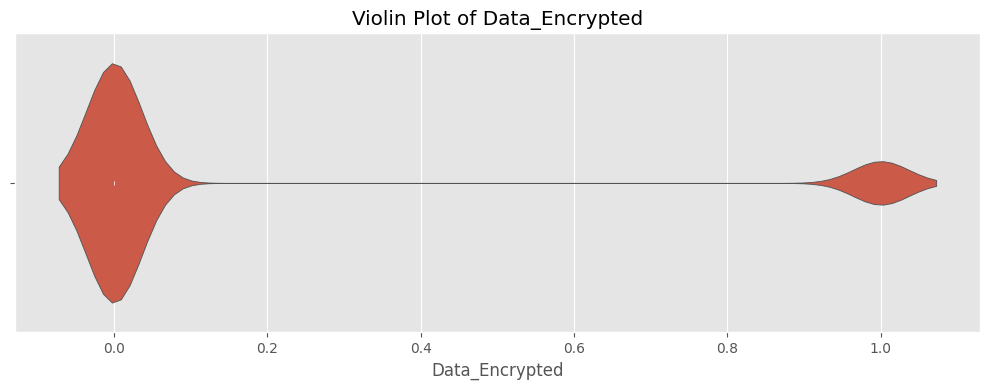

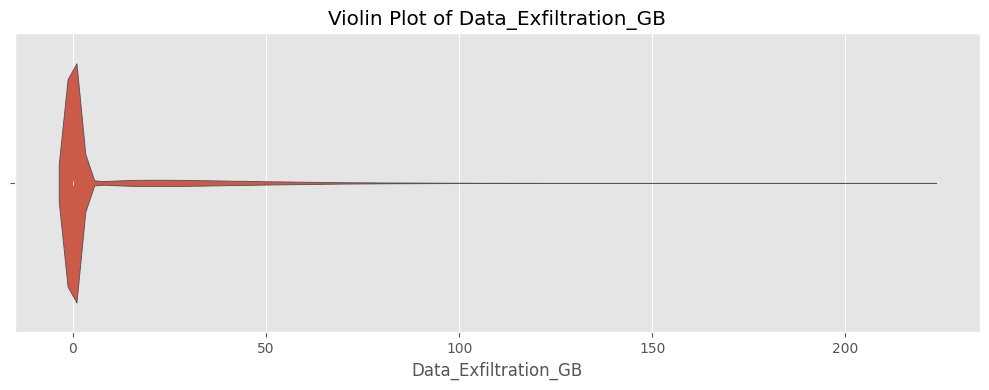

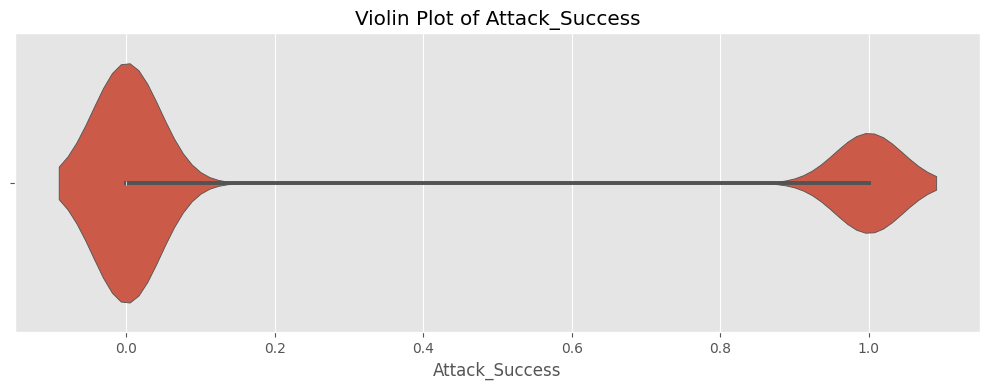

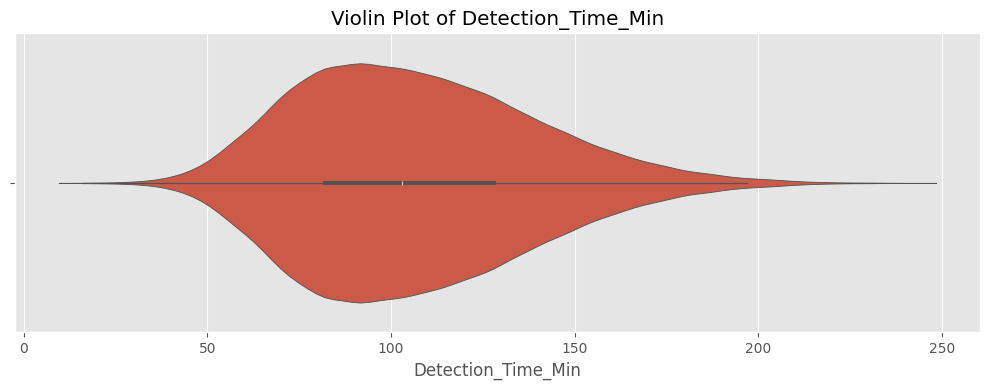

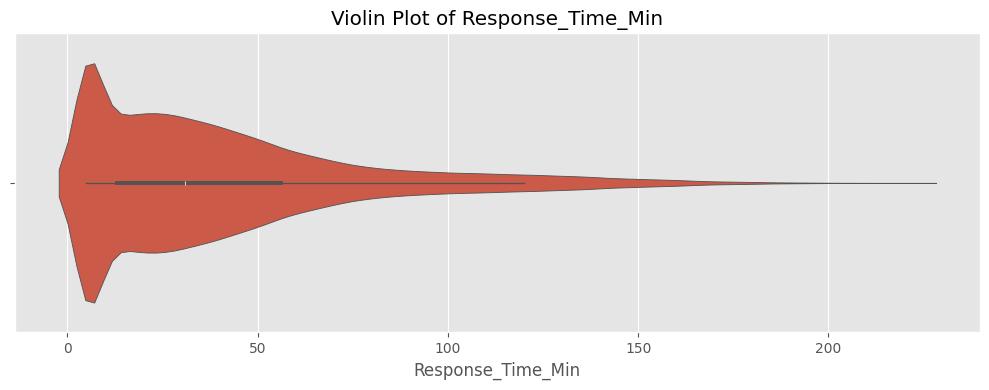

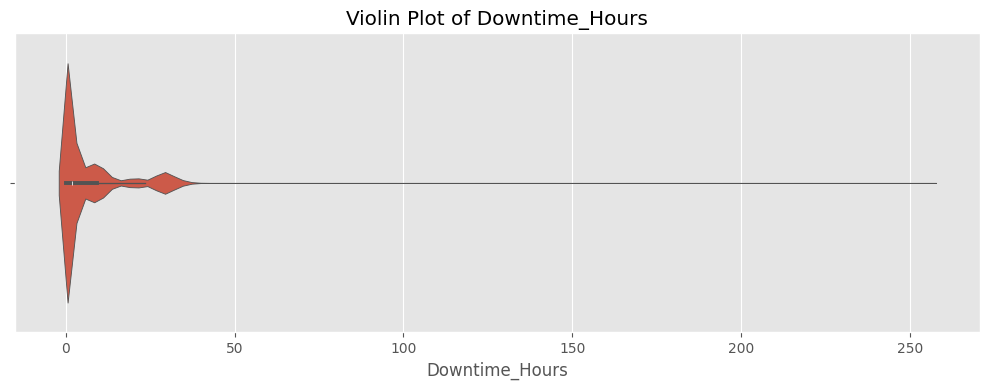

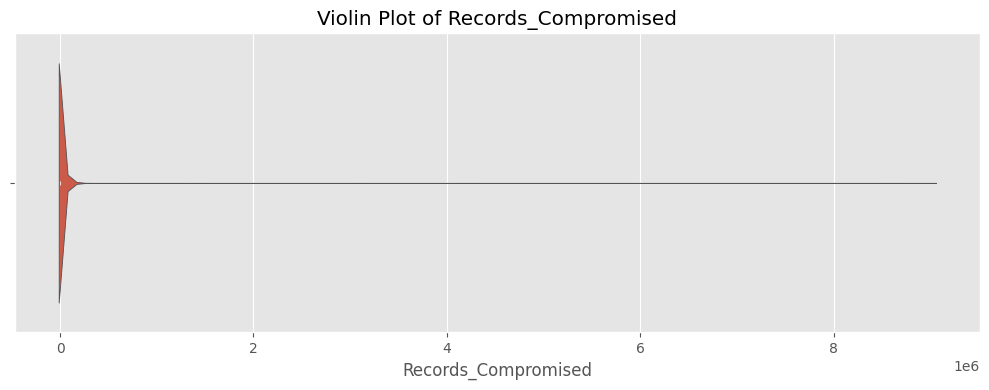

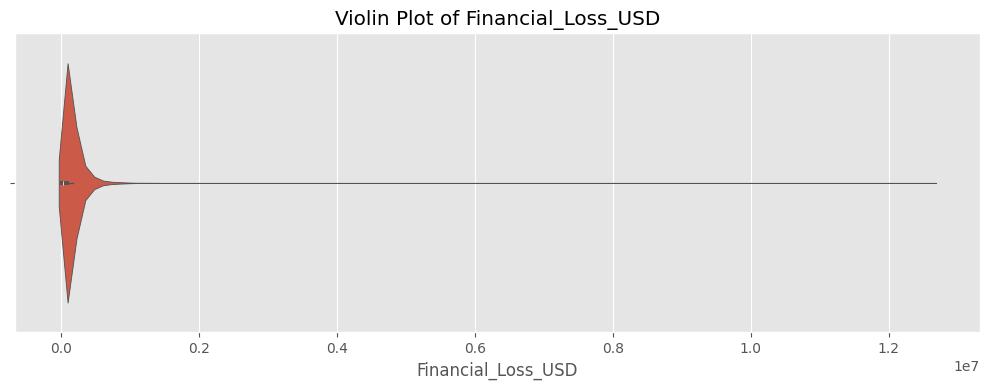

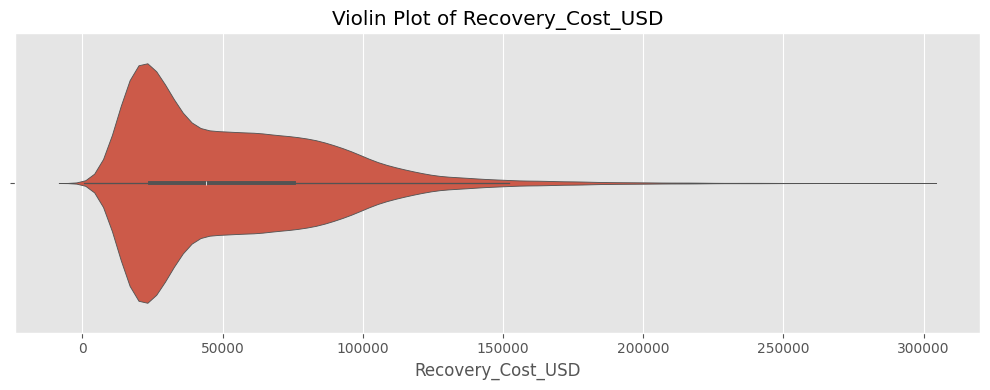

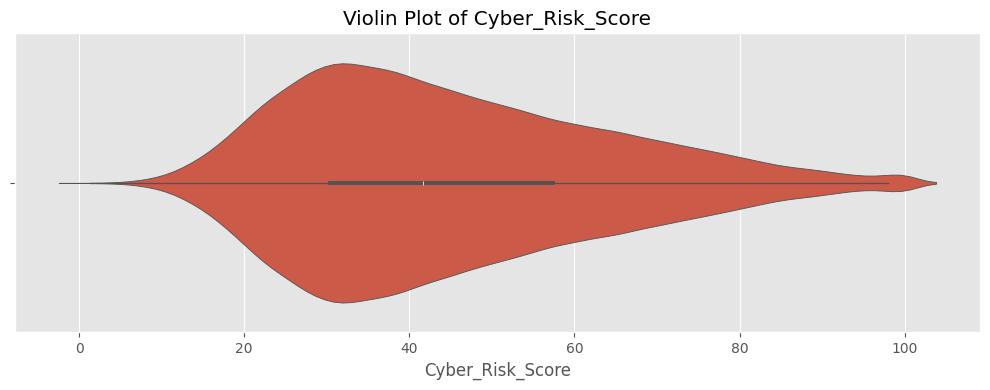

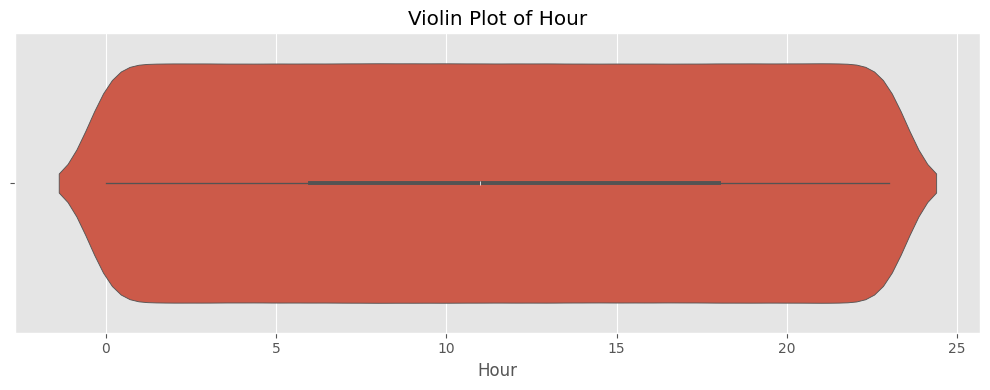

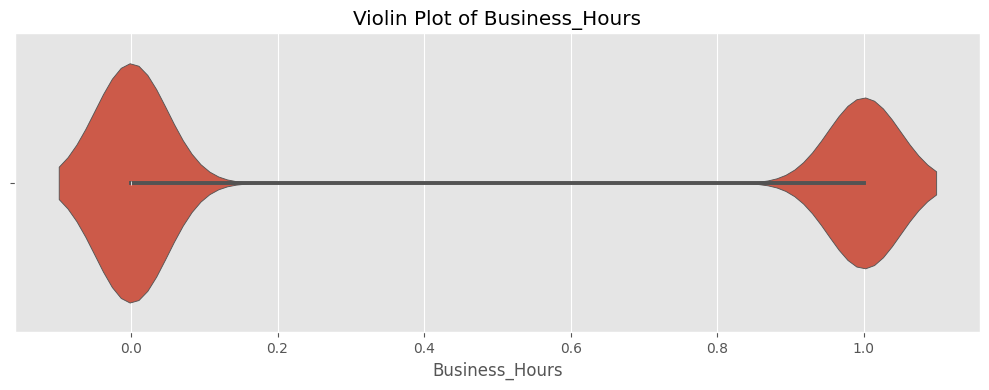

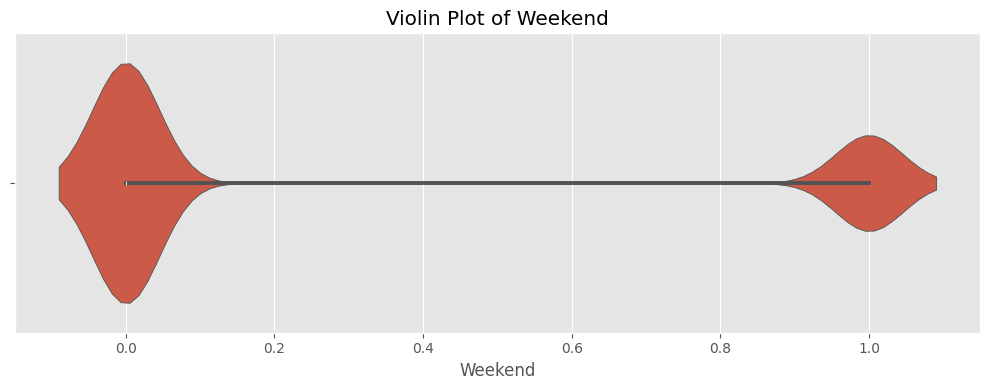

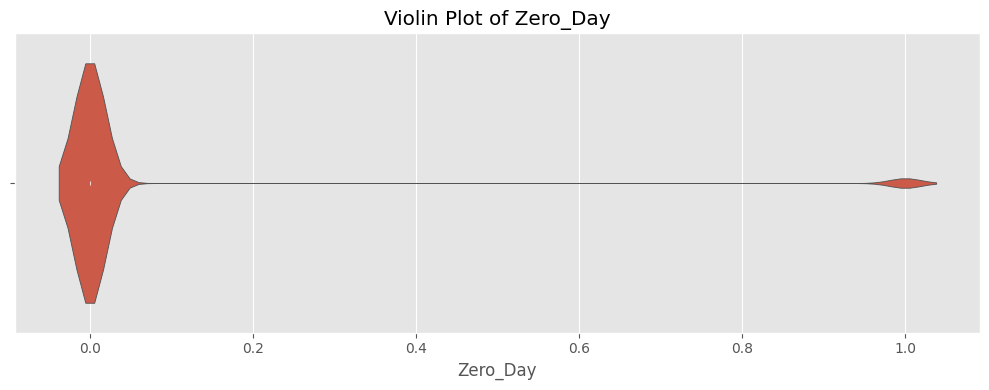

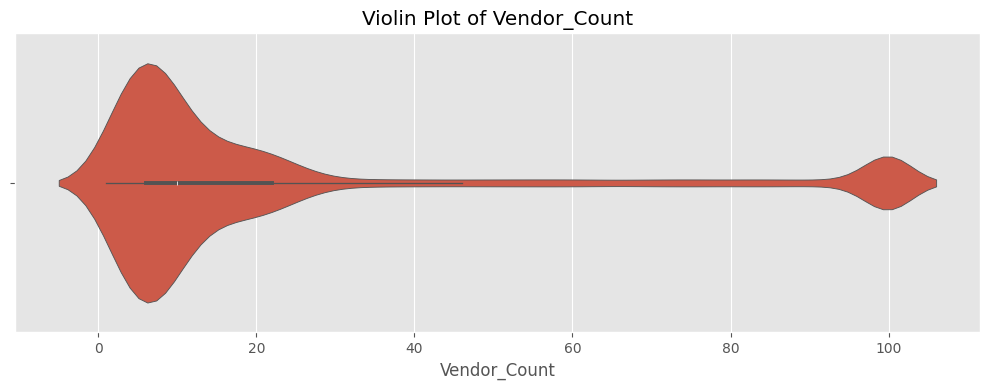

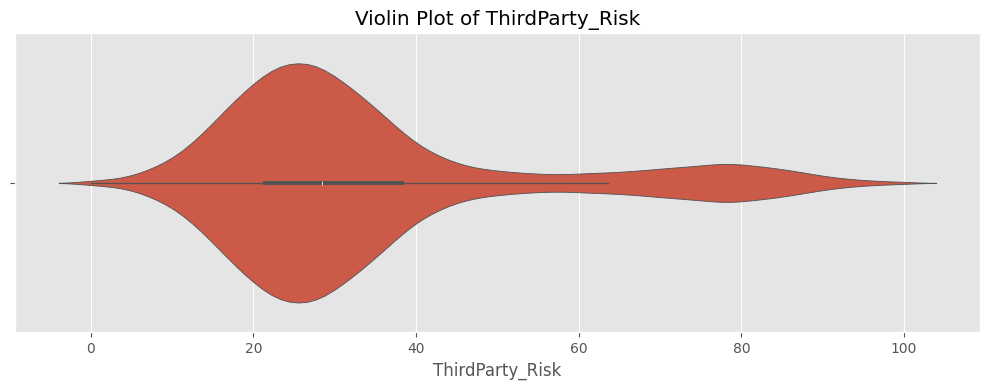

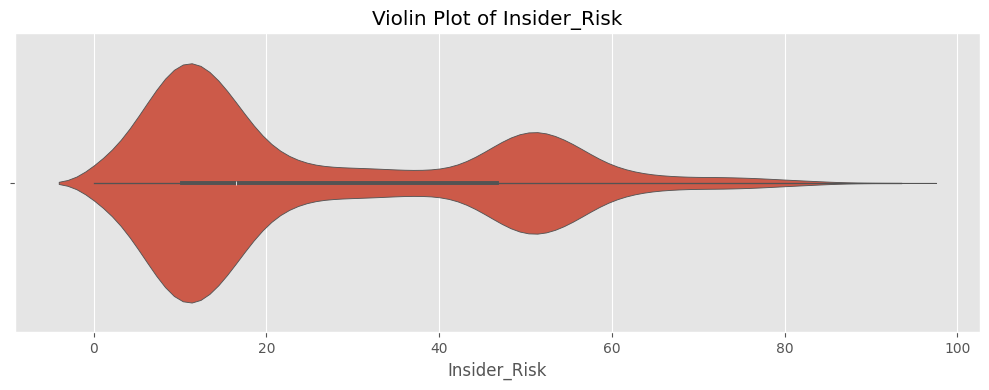

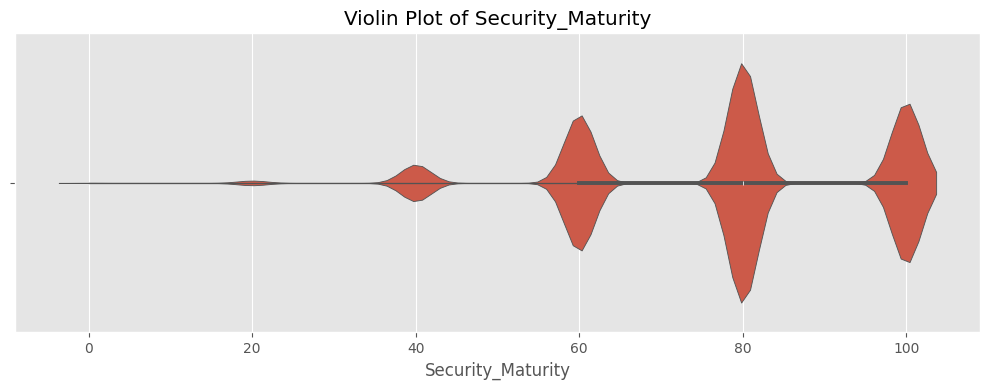

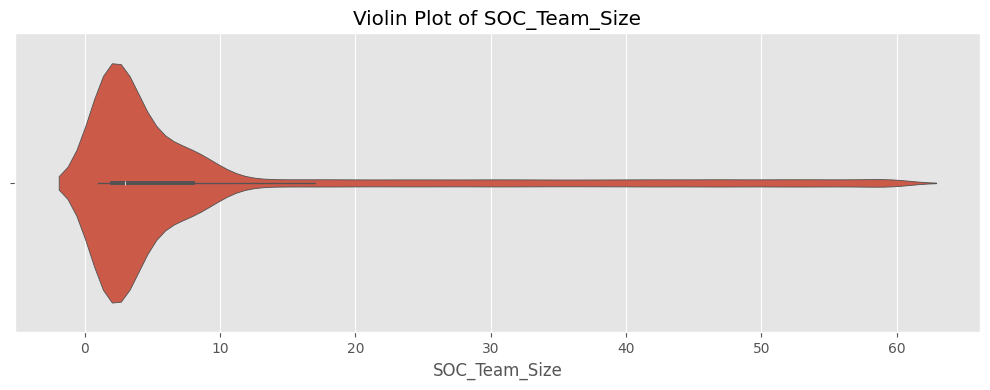

In [12]:
# ============================================================
# Violin Plots
# ============================================================

for column in numerical_columns:

    plt.figure(figsize=(10,4))

    sns.violinplot(
        x=df[column]
    )

    plt.title(f"Violin Plot of {column}")

    plt.tight_layout()

    plt.show()

In [13]:
# ============================================================
# Percentage Distribution
# ============================================================

for column in categorical_columns:

    percentage = (
        df[column]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    display(
        pd.DataFrame({
            "Percentage": percentage
        })
    )

,Percentage
Timestamp,
2023-01-06 23:45:00,0.00
2025-04-06 18:30:00,0.00
2025-05-28 13:00:00,0.00
2025-09-03 21:00:00,0.00
2024-06-12 19:30:00,0.00
...,...
2024-04-27 18:15:00,0.00
2024-08-16 15:30:00,0.00
2024-03-05 08:15:00,0.00


,Percentage
Industry,
Banking,18.02
Technology,16.07
Healthcare,15.07
Retail,13.88
Manufacturing,12.04
Education,8.98
Government,8.07
Telecom,7.87


,Percentage
Country,
UK,12.67
Singapore,12.62
Germany,12.50
Australia,12.49
India,12.48
Canada,12.48
USA,12.46
Japan,12.32


,Percentage
Company_Size,
Small,50.00
Medium,29.97
Large,20.04


,Percentage
Attack_Vector,
Email,35.12
Web,17.93
Cloud,11.97
API,10.10
VPN,9.95
RDP,9.90
USB,5.04


...

,Percentage
Risk_Level,
Medium,51.01
High,26.97
Low,13.67
Critical,8.35


,Percentage
Incident_Severity,
Moderate,52.75
Major,30.51
Severe,10.92
Minor,5.82


,Percentage
DayOfWeek,
Wednesday,14.31
Monday,14.31
Tuesday,14.30
Thursday,14.30
Sunday,14.30
Friday,14.27
Saturday,14.21


,Percentage
Month,
October,8.93
July,8.93
January,8.93
May,8.93
March,8.93
August,8.92
June,8.65
April,8.63
September,8.63


,Percentage
Compliance,
PCI-DSS,31.48
ISO27001,28.08
HIPAA,26.34
NIST,14.10


## Data Cleaning

Before any modeling, three cleaning steps are required: remove exact duplicate records, drop columns that leak post-breach information, and impute the remaining missing values.

In [2]:
# ============================================================
# Remove Duplicate Records
# ============================================================

before = df.shape[0]

df = df.drop_duplicates().reset_index(drop=True)

after = df.shape[0]

print(f"Duplicate rows removed : {before - after:,}")
print(f"Dataset shape after deduplication : {df.shape}")

Duplicate rows removed : 500
Dataset shape after deduplication : (100000, 50)


### Remove Post-Breach Leakage Columns

`Recovery_Cost_USD`, `Records_Compromised`, `Downtime_Hours`, `Financial_Loss_USD`, `Cyber_Risk_Score`, `Risk_Level`, and `Incident_Severity` are all measured or derived *after* a breach has already happened. Leaving them in the feature set would let the model see the answer before making its prediction, so they are dropped here.

In [3]:
# ============================================================
# Remove Post-Breach Leakage Columns
# ============================================================
#
# These columns are only populated / meaningful AFTER a breach has
# already occurred (recovery cost, records compromised, downtime,
# financial loss, and the risk/severity scores derived from them).
# Keeping them in the feature set would leak the target variable
# (Attack_Success) directly into the model and produce artificially
# inflated accuracy that would not generalize to real-world use,
# where the model must predict success/containment WHILE an attack
# is still in progress.

leakage_columns = [
    "Recovery_Cost_USD",
    "Records_Compromised",
    "Downtime_Hours",
    "Financial_Loss_USD",
    "Cyber_Risk_Score",
    "Risk_Level",
    "Incident_Severity",
]

print("Missing % for leakage-suspect columns BEFORE dropping:")
display(df[leakage_columns].isnull().mean().mul(100).round(2).to_frame("Missing %"))

df = df.drop(columns=leakage_columns)

print(f"\nDropped {len(leakage_columns)} leakage columns.")
print(f"Remaining shape : {df.shape}")

Missing % for leakage-suspect columns BEFORE dropping:


,Missing %
Recovery_Cost_USD,70.59
Records_Compromised,0.00
Downtime_Hours,0.00
Financial_Loss_USD,5.01
Cyber_Risk_Score,0.00
Risk_Level,0.00
Incident_Severity,0.00



Dropped 7 leakage columns.
Remaining shape : (100000, 43)


### Impute Remaining Missing Values

In [4]:
# ============================================================
# Handle Remaining Missing Values
# ============================================================

print("Missing values remaining before imputation:")
display(df.isnull().sum()[df.isnull().sum() > 0].to_frame("Missing Values"))

# Compliance is NaN for enterprises in unregulated sectors -> treat as its own category
df["Compliance"] = df["Compliance"].fillna("None")

# Detection_Time_Min: impute with the median (robust to skew/outliers)
median_detection_time = df["Detection_Time_Min"].median()
df["Detection_Time_Min"] = df["Detection_Time_Min"].fillna(median_detection_time)

print(f"\n'Compliance' NaNs filled with 'None' (unregulated sector).")
print(f"'Detection_Time_Min' NaNs filled with median = {median_detection_time:.2f} minutes.")
print(f"\nTotal remaining missing values: {df.isnull().sum().sum()}")

Missing values remaining before imputation:


,Missing Values
Detection_Time_Min,3147
Compliance,42772



'Compliance' NaNs filled with 'None' (unregulated sector).
'Detection_Time_Min' NaNs filled with median = 103.00 minutes.

Total remaining missing values: 0


## Feature Set & Target Variable

With the data clean, define `Attack_Success` as the binary target (0 = contained/mitigated, 1 = breach succeeded) and drop identifier columns that carry no predictive signal.

In [5]:
# ============================================================
# Target Variable & Feature Set
# ============================================================

# Incident_ID is a unique identifier with no predictive value.
# Timestamp has already been decomposed into Hour, DayOfWeek, Month,
# Business_Hours, and Weekend, so the raw timestamp is redundant.
df_model = df.drop(columns=["Incident_ID", "Timestamp"])

target = "Attack_Success"

X = df_model.drop(columns=[target])
y = df_model[target]

print(f"Feature matrix shape : {X.shape}")
print("\nTarget class distribution:")
display(y.value_counts(normalize=True).mul(100).round(2).to_frame("Percentage"))

plt.figure(figsize=(5, 4))
sns.countplot(x=y)
plt.title("Class Balance - Attack_Success")
plt.xlabel("Attack Success (0 = Contained, 1 = Breached)")
plt.tight_layout()
plt.show()

Feature matrix shape : (100000, 40)

Target class distribution:


,Percentage
Attack_Success,
0,70.59
1,29.41


### Kill Chain Stage vs. Breach Outcome

A quick sanity check on the cleaned data: how far an attacker gets through the kill chain should be strongly related to whether the attack ultimately succeeds.

In [6]:
# ============================================================
# Breach Success Rate by Kill Chain Stage Reached
# ============================================================

stage_success = (
    df_model.groupby("Attack_Stage")[target]
    .mean()
    .mul(100)
    .round(2)
    .sort_values()
)

display(stage_success.to_frame("Attack Success Rate (%)"))

plt.figure(figsize=(10, 5))
sns.barplot(x=stage_success.index, y=stage_success.values, order=stage_success.index)
plt.ylabel("Attack Success Rate (%)")
plt.xlabel("Kill Chain Stage Reached")
plt.title("Breach Success Rate by Kill Chain Stage")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

,Attack Success Rate (%)
Attack_Stage,
Reconnaissance,4.73
Initial Access,38.63
Execution,56.09
Persistence,73.24
Impact,93.80


## Train-Test Split & Preprocessing Pipeline

Categorical features are one-hot encoded; numerical features pass through unchanged. This is wrapped in a `ColumnTransformer` so the exact same preprocessing is applied consistently at train and inference time.

In [7]:
# ============================================================
# Train-Test Split & Preprocessing Pipeline
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Categorical features ({len(categorical_features)}):")
print(categorical_features)
print(f"\nNumerical features ({len(numerical_features)}):")
print(numerical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="passthrough",
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")

Categorical features (11):
['Industry', 'Country', 'Company_Size', 'Attack_Vector', 'Threat_Actor', 'Password_Policy', 'Attack_Stage', 'Attack_Complexity', 'DayOfWeek', 'Month', 'Compliance']

Numerical features (29):
['Employee_Count', 'Firewall', 'MFA', 'EDR', 'IDS', 'Security_Training', 'Patch_Age_Days', 'Open_Vulnerabilities', 'CVSS_Score', 'Internet_Exposed', 'Security_Audit_Score', 'Phishing_Click', 'Credential_Stolen', 'Privilege_Escalation', 'Lateral_Movement', 'Persistence', 'Data_Encrypted', 'Data_Exfiltration_GB', 'Detection_Time_Min', 'Response_Time_Min', 'Hour', 'Business_Hours', 'Weekend', 'Zero_Day', 'Vendor_Count', 'ThirdParty_Risk', 'Insider_Risk', 'Security_Maturity', 'SOC_Team_Size']

Training set : (80000, 40)
Test set     : (20000, 40)


## Baseline Model: Logistic Regression

A simple linear baseline to compare the Random Forest against.

In [8]:
# ============================================================
# Baseline Model - Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Performance")
print("-" * 50)
print(f"Accuracy : {lr_accuracy * 100:.2f}%")
print(f"F1 Score : {lr_f1:.4f}")
print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance
--------------------------------------------------
Accuracy : 86.39%
F1 Score : 0.7685

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     14119
           1       0.77      0.77      0.77      5881

    accuracy                           0.86     20000
   macro avg       0.84      0.84      0.84     20000
weighted avg       0.86      0.86      0.86     20000



## Random Forest Classifier

An ensemble of decision trees (bagging + Gini-impurity splits), depth-limited (`max_depth=12`, `min_samples_leaf=5`) so the saved model stays a manageable size without sacrificing accuracy. This is the primary model for this project.

In [9]:
# ============================================================
# Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )),
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_proba_rf)

print("Random Forest Performance")
print("-" * 50)
print(f"Accuracy : {rf_accuracy * 100:.2f}%")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")
print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
--------------------------------------------------
Accuracy : 86.42%
F1 Score : 0.7695
ROC-AUC  : 0.9348

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     14119
           1       0.77      0.77      0.77      5881

    accuracy                           0.86     20000
   macro avg       0.84      0.84      0.84     20000
weighted avg       0.86      0.86      0.86     20000



### Confusion Matrices

In [10]:
# ============================================================
# Confusion Matrices
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

## Model Comparison

In [11]:
# ============================================================
# Model Comparison
# ============================================================

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy (%)": [lr_accuracy * 100, rf_accuracy * 100],
    "F1 Score": [lr_f1, rf_f1],
})

display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x="Model", y="Accuracy (%)", hue="Model", data=comparison, ax=axes[0], palette="viridis", legend=False)
axes[0].set_ylim(0, 100)
axes[0].set_title("Accuracy Comparison")

sns.barplot(x="Model", y="F1 Score", hue="Model", data=comparison, ax=axes[1], palette="magma", legend=False)
axes[1].set_ylim(0, 1)
axes[1].set_title("F1 Score Comparison")

plt.tight_layout()
plt.show()

,Model,Accuracy (%),F1 Score
0,Logistic Regression,86.39,0.77
1,Random Forest,86.42,0.77


### Feature Importance (Random Forest)

Which signals drive the model's predictions the most.

In [12]:
# ============================================================
# Feature Importance (Random Forest)
# ============================================================

ohe_columns = (
    rf_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = list(ohe_columns) + numerical_features

importances = rf_pipeline.named_steps["classifier"].feature_importances_

feat_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances,
}).sort_values("Importance", ascending=False).head(20)

display(feat_importance)

plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", hue="Feature", data=feat_importance, palette="rocket", legend=False)
plt.title("Top 20 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

,Feature,Importance
80,Lateral_Movement,0.18
38,Attack_Stage_Reconnaissance,0.16
79,Privilege_Escalation,0.12
81,Persistence,0.10
84,Detection_Time_Min,0.06
78,Credential_Stolen,0.05
37,Attack_Stage_Persistence,0.04
35,Attack_Stage_Impact,0.04
83,Data_Exfiltration_GB,0.04
82,Data_Encrypted,0.03


## Save the Trained Model

Persist the full pipeline (preprocessing + classifier) so it can be loaded directly by the Streamlit prototype without needing to refit.

In [13]:
# ============================================================
# Save Trained Model
# ============================================================

import joblib

joblib.dump(rf_pipeline, "cyber_model.joblib")

print("Model saved to cyber_model.joblib")
print("\nFinal Summary")
print("-" * 50)
print(f"Random Forest       -> Accuracy: {rf_accuracy*100:.2f}% | F1: {rf_f1:.4f} | ROC-AUC: {rf_auc:.4f}")
print(f"Logistic Regression -> Accuracy: {lr_accuracy*100:.2f}% | F1: {lr_f1:.4f}")

Model saved to cyber_model.joblib

Final Summary
--------------------------------------------------
Random Forest       -> Accuracy: 86.42% | F1: 0.7695 | ROC-AUC: 0.9348
Logistic Regression -> Accuracy: 86.39% | F1: 0.7685
